In [2]:
# Visualize one data set of GCOPTER vs MIGHTY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
from matplotlib import font_manager
import re, math

# Font settings
font = font_manager.FontProperties()
font.set_family('serif')
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = "Times New Roman"
font.set_size(25)

# If you want to force specific CSVs, set these; otherwise we’ll use ExportCSVDir from YAML
gc_csv_override = None  # e.g., Path("/home/kkondo/data/gcopter_csv/gcopter_vaj.csv")
my_csv_override = None  # e.g., Path("/home/kkondo/data/gcopter_csv/mighty_vaj.csv")

ROOT_DIR = Path("/media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/case_00024_v4.00_jw1e-1/goal_008")
# ROOT_DIR = Path("/media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/case_00048_v3.00_jw1e-5/goal_001")
gc_csv_override = ROOT_DIR / "gcopter_vaj.csv"
my_csv_override = ROOT_DIR / "mighty_vaj.csv"

if True:

    def load_ros2_params(yaml_path: Path) -> dict:
        """
        Loads a ROS2 parameter YAML. Returns the 'ros__parameters' dict if present,
        otherwise the top-level dict.
        Supports these common shapes:
        1) { "/**": { "ros__parameters": {...} } }
        2) { "node": { "ros__parameters": {...} } }
        3) { "ros__parameters": {...} }
        4) flat dict of params
        """
        with open(yaml_path, "r") as f:
            y = yaml.safe_load(f)
        if not isinstance(y, dict):
            return {}
        # Try 1 & 2
        for k, v in y.items():
            if isinstance(v, dict) and "ros__parameters" in v:
                return dict(v["ros__parameters"])
        # Try 3
        if "ros__parameters" in y and isinstance(y["ros__parameters"], dict):
            return dict(y["ros__parameters"])
        # Fallback 4
        return y

    # Cell 2: helpers to extract dynamics + plotting

    def _first_col(df: pd.DataFrame, candidates):
        """Return the first present column as numpy array, else None."""
        for c in candidates:
            if c in df.columns:
                return df[c].to_numpy()
        return None

    def _norm_from_components(df, cand_x, cand_y, cand_z):
        x = _first_col(df, cand_x)
        y = _first_col(df, cand_y)
        z = _first_col(df, cand_z)
        if x is None or y is None or z is None:
            return None
        return np.sqrt(x*x + y*y + z*z)

    def extract_dyn(df: pd.DataFrame, g: float, mass: float):
        """
        Extract time histories needed for plotting:
        t, speed (|v|), omega (|ω|), tilt_rad, thrust (N)
        Falls back to compute from (a, j) if omega/tilt/thrust are not logged.
        """
        out = {}

        # time
        out["t"] = _first_col(df, ["t", "time", "sec", "timestamp"])
        if out["t"] is None:
            raise ValueError("Couldn't find a time column (t/time/sec/timestamp).")

        # speed |v|
        sp = _first_col(df, ["v_norm", "speed", "speed_norm", "|v|"])
        if sp is None:
            sp = _norm_from_components(df, ["vx"], ["vy"], ["vz"])
        out["speed"] = sp

        # body-rate |ω|
        om = _first_col(df, ["omega_norm", "om_norm", "w_norm", "|omega|", "|w|"])
        if om is None:
            # derive from a, j using b = (a + g e3)/||...||, bdot = (I - b b^T) j / ||a+ge3||
            ax = _first_col(df, ["ax"]); ay = _first_col(df, ["ay"]); az = _first_col(df, ["az"])
            jx = _first_col(df, ["jx"]); jy = _first_col(df, ["jy"]); jz = _first_col(df, ["jz"])
            if None not in (ax, ay, az, jx, jy, jz):
                nz = az + g
                r = np.sqrt(ax*ax + ay*ay + nz*nz) + 1e-12
                bx, by, bz = ax/r, ay/r, nz/r
                # P * j = j - (b·j) b
                bj = bx*jx + by*jy + bz*jz
                px = jx - bj*bx
                py = jy - bj*by
                pz = jz - bj*bz
                om = np.sqrt(px*px + py*py + pz*pz) / r
        out["omega"] = om

        # tilt (rad)
        tilt_rad = _first_col(df, ["tilt", "tilt_rad"])
        if tilt_rad is None:
            tilt_deg = _first_col(df, ["tilt_deg"])
            if tilt_deg is not None:
                tilt_rad = np.deg2rad(tilt_deg)
        if tilt_rad is None:
            # try cos(theta) or b3z
            cos_t = _first_col(df, ["cos_t", "cost", "cos_theta", "b3z", "bz"])
            if cos_t is not None:
                tilt_rad = np.arccos(np.clip(cos_t, -1.0, 1.0))
        if tilt_rad is None:
            # derive from a + g e3
            ax = _first_col(df, ["ax"]); ay = _first_col(df, ["ay"]); az = _first_col(df, ["az"])
            if None not in (ax, ay, az):
                nz = az + g
                r = np.sqrt(ax*ax + ay*ay + nz*nz) + 1e-12
                tilt_rad = np.arccos(np.clip(nz / r, -1.0, 1.0))
        out["tilt_rad"] = tilt_rad

        # thrust (N)
        thr = _first_col(df, ["thrust", "f", "T"])
        if thr is None:
            # derive from a + g e3
            ax = _first_col(df, ["ax"]); ay = _first_col(df, ["ay"]); az = _first_col(df, ["az"])
            if None not in (ax, ay, az):
                r = np.sqrt(ax*ax + ay*ay + (az + g)*(az + g))
                thr = mass * r
        out["thrust"] = thr

        return out

    def plot_overlay(gc, my,
                    V_max=None, Omega_max=None, tilt_max=None,
                    f_min=None, f_max=None,
                    tilt_units="deg", sharex=True):
        """
        One 2x2 figure overlaying GCOPTER vs MIGHTY:
        TL: |v|, TR: |ω|, BL: tilt, BR: thrust
        Draws horizontal limits when provided.
        """
        def tilt_for_plot(rad):
            if rad is None:
                return None, "Tilt"
            return (np.degrees(rad), "Tilt [deg]") if tilt_units == "deg" else (rad, "Tilt [rad]")

        tilt_gc, tilt_label = tilt_for_plot(gc["tilt_rad"])
        tilt_my, _ = tilt_for_plot(my["tilt_rad"])
        tlim = None if tilt_max is None else (np.degrees(tilt_max) if tilt_units == "deg" else tilt_max)

        fig, ax = plt.subplots(2, 2, figsize=(15, 8), sharex=sharex)
        (ax11, ax12), (ax21, ax22) = ax

        # Speed
        ax11.plot(gc["t"], gc["speed"], label="GCOPTER", color="red", alpha=0.7)
        ax11.plot(my["t"], my["speed"], label="MIGHTY", color="green", alpha=0.7)
        if V_max is not None:
            ax11.axhline(V_max, linestyle=":", label="Max Velocity")
        ax11.set_ylabel("Speed [m/s] ", fontproperties=font)
        ax11.set_title("Speed", fontproperties=font)
        ax11.grid(True); ax11.legend(fontsize=15)

        # Body-rate
        ax12.plot(gc["t"], gc["omega"], label="GCOPTER", color="red", alpha=0.7)
        ax12.plot(my["t"], my["omega"], label="MIGHTY", color="green", alpha=0.7)
        if Omega_max is not None:
            ax12.axhline(Omega_max, linestyle=":", label="Max Angular Vel.")
        ax12.set_ylabel("Angular Vel. [rad/s]", fontproperties=font)
        ax12.set_title("Angular Vel.", fontproperties=font)
        ax12.grid(True); ax12.legend(fontsize=15)

        # Tilt
        ax21.plot(gc["t"], tilt_gc, label="GCOPTER", color="red", alpha=0.7)
        ax21.plot(my["t"], tilt_my, label="MIGHTY", color="green", alpha=0.7)
        if tlim is not None:
            ax21.axhline(tlim, linestyle=":", label="Max Tilt")
        ax21.set_xlabel("t [s]", fontproperties=font)
        ax21.set_ylabel(tilt_label, fontproperties=font)
        ax21.set_title("Tilt", fontproperties=font)
        if tilt_gc is not None and tilt_my is not None:
            ymax = np.nanmax([np.nanmax(tilt_gc), np.nanmax(tilt_my), (tlim if tlim is not None else 0)])
            ax21.set_ylim([0, max(1e-6, 1.1*ymax)])
        ax21.grid(True); ax21.legend(fontsize=15)

        # Thrust
        ax22.plot(gc["t"], gc["thrust"], label="GCOPTER", color="red", alpha=0.7)
        ax22.plot(my["t"], my["thrust"], label="MIGHTY", color="green", alpha=0.7)
        if f_min is not None:
            ax22.axhline(f_min, linestyle=":", label="Min Thrust")
        if f_max is not None:
            ax22.axhline(f_max, linestyle=":", label="Max Thrust")
        ax22.set_xlabel("t [s]", fontproperties=font)
        ax22.set_ylabel("Thrust [N]", fontproperties=font)
        ax22.set_title("Thrust", fontproperties=font)
        ax22.grid(True); ax22.legend(fontsize=15)

        # make ticks larger
        ax22.tick_params(axis='both', which='major', labelsize=16)
        ax21.tick_params(axis='both', which='major', labelsize=16)
        ax12.tick_params(axis='both', which='major', labelsize=16)
        ax11.tick_params(axis='both', which='major', labelsize=16)

        fig.tight_layout()
        return fig


    def plot_history(export_dir=None, max_vel=None, save_path=None):

        # Cell 3: configure paths, load data, plot

        # --- paths (edit if needed) ---
        yaml_path = Path("/home/kkondo/code/gcopter_ws/src/GCOPTER/gcopter/config/global_planning.yaml")   # <- set this

        # --- load params from YAML ---
        params = load_ros2_params(yaml_path)

        if export_dir is None:
            export_dir = Path(params.get("ExportCSVDir", "/home/kkondo/data/gcopter_csv"))
            gc_csv = gc_csv_override if gc_csv_override is not None else (export_dir / "gcopter_vaj.csv")
            my_csv = my_csv_override if my_csv_override is not None else (export_dir / "mighty_vaj.csv")
        else:
            # --- CSV paths (override if provided above) ---
            gc_csv = gc_csv_override if gc_csv_override is not None else (export_dir + "/gcopter_vaj.csv")
            my_csv = my_csv_override if my_csv_override is not None else (export_dir + "/mighty_vaj.csv")

        if max_vel is None:
            V_max      = params.get("MaxVelMag", None)
        else:
            V_max = max_vel
        Omega_max  = params.get("MaxBdrMag", None)
        tilt_max   = params.get("MaxTiltAngle", None)  # YAML already in radians
        f_min      = params.get("MinThrust", None)
        f_max      = params.get("MaxThrust", None)
        mass       = params.get("VehicleMass", 1.0)
        g          = params.get("GravAcc", 9.81)
        crop_common_time = False

        print("GCOPTER CSV:", gc_csv)
        print("MIGHTY  CSV:", my_csv)

        gc_df = pd.read_csv(gc_csv)
        my_df = pd.read_csv(my_csv)

        # --- extract dynamics using mass, g from YAML ---
        gc = extract_dyn(gc_df, g=g, mass=mass)
        my = extract_dyn(my_df, g=g, mass=mass)

        # Optional: crop both to common max time
        if crop_common_time:
            tmax = min(np.max(gc["t"]), np.max(my["t"]))
            sel_gc = gc["t"] <= tmax
            sel_my = my["t"] <= tmax
            for k in gc.keys():
                if gc[k] is not None:
                    gc[k] = gc[k][sel_gc]
            for k in my.keys():
                if my[k] is not None:
                    my[k] = my[k][sel_my]

        # --- plot (tilt in degrees is usually nicer) ---
        fig = plot_overlay(
            gc, my,
            V_max=V_max, Omega_max=Omega_max,
            tilt_max=tilt_max, f_min=f_min, f_max=f_max,
            tilt_units="deg", sharex=True
        )

        if save_path is not None:
            fig.savefig(save_path, bbox_inches='tight', dpi=500)
            print(f"Saved figure to {save_path}")
        else:
            plt.show()
    
    def plot_vel_history(exprt_dir=None, max_vel=None, save_path=None):
        """
        Plot |v| over time for GCOPTER vs MIGHTY.

        Args:
            exprt_dir: Directory (str or Path) containing 'gcopter_vaj.csv' and 'mighty_vaj.csv'.
                    If None, falls back to ExportCSVDir from YAML (and any *_override paths).
            max_vel:   Optional float for horizontal max-velocity line. If None, uses YAML MaxVelMag.
            save_path: Optional path to save the figure; if None, displays interactively.

        Returns:
            (fig, ax) for further tweaking if desired.
        """
        # --- YAML params (adjust path if needed) ---
        yaml_path = Path("/home/kkondo/code/gcopter_ws/src/GCOPTER/gcopter/config/global_planning.yaml")
        params = load_ros2_params(yaml_path)

        # --- Resolve CSV paths ---
        if exprt_dir is None:
            base = Path(params.get("ExportCSVDir", "/home/kkondo/data/gcopter_csv"))
        else:
            base = Path(exprt_dir)

        gc_csv = gc_csv_override if gc_csv_override is not None else (base / "gcopter_vaj.csv")
        my_csv = my_csv_override if my_csv_override is not None else (base / "mighty_vaj.csv")

        print("GCOPTER CSV:", gc_csv)
        print("MIGHTY  CSV:", my_csv)

        # --- Limits / constants ---
        V_max = params.get("MaxVelMag", None) if max_vel is None else max_vel
        mass  = params.get("VehicleMass", 1.0)
        g     = params.get("GravAcc", 9.81)

        # --- Load & extract ---
        gc_df = pd.read_csv(gc_csv)
        my_df = pd.read_csv(my_csv)
        gc = extract_dyn(gc_df, g=g, mass=mass)
        my = extract_dyn(my_df, g=g, mass=mass)

        if gc.get("t") is None or gc.get("speed") is None:
            raise ValueError("GCOPTER CSV missing time/speed columns (or components to build them).")
        if my.get("t") is None or my.get("speed") is None:
            raise ValueError("MIGHTY CSV missing time/speed columns (or components to build them).")

        # --- Plot ---
        fig, ax = plt.subplots(figsize=(9, 3))
        ax.plot(gc["t"], gc["speed"], label="GCOPTER", color="red", alpha=0.7, linewidth=3)
        ax.plot(my["t"], my["speed"], label="MIGHTY", color="green", alpha=0.7, linewidth=3)
        if V_max is not None:
            ax.axhline(V_max, linestyle=":", label="Max Velocity")

        ax.set_xlabel("t [s]", fontproperties=font)
        ax.set_ylabel("Speed [m/s]", fontproperties=font)
        ax.set_title("Speed", fontproperties=font)
        ax.grid(True)
        ax.legend(fontsize=15)
        ax.tick_params(axis='both', which='major', labelsize=16)

        fig.tight_layout()

        if save_path is not None:
            fig.savefig(save_path, bbox_inches='tight', dpi=500)
            print(f"Saved figure to {save_path}")
        else:
            plt.show()

        return fig, ax

# plot
# plot_history()


In [3]:
# Drop-in analysis cell for GCOPTER/MIGHTY simple benchmarking results
# - Scans case_* / goal_* directories
# - Reads bench_stats.csv for performance + collisions
# - Reads gcopter_vaj.csv / mighty_vaj.csv to count dynamic-constraint violations
# - Produces two CSVs: case_summary.csv and goal_summary.csv under <ROOT_DIR>/analysis_summary
# - Displays both tables

# ============================== User-config ==============================
# Root directory that contains case_* folders:
DATA_NUMBER = "2"
ROOT_DIR_STR = f"/media/kkondo/lucas_pro/mighty_gcopter_bench/simple_bench/data{DATA_NUMBER}"
# ROOT_DIR_STR = "/media/kkondo/lucas_pro/mighty_gcopter_bench/simple_bench"
ROOT_DIR = Path(ROOT_DIR_STR)
gc_csv_override = None  # e.g., Path("/home/kkondo/data/gcopter_csv/gcopter_vaj.csv")
my_csv_override = None  # e.g., Path("/home/kkondo/data/gcopter_csv/mighty_vaj.csv")

# Allowed relative violation (e.g., 0.01 = 1%, 0.02 = 2%)
ALLOW_VIOL_PCT = 0.01  # change to 0.02 if you allow 2%

# Dynamic limits (used for body-rate / tilt / thrust). Velocity limit is read per goal from bench_stats.csv:max_vel.
# Set these to match your run; defaults mirror typical values in your node.
MAX_BODYRATE = 2.1           # rad/s
MAX_TILT_RAD = 1.05          # rad
THRUST_MIN   = 2.0           # N
THRUST_MAX   = 12.0          # N

# Where to write the summaries
OUT_DIR = ROOT_DIR / "analysis_summary"
OUT_DIR.mkdir(parents=True, exist_ok=True)
# ========================================================================

PLANNERS = ("gc", "my")  # "gc" = GCOPTER, "my" = MIGHTY
VAJ_FILENAMES = {"gc": "gcopter_vaj.csv", "my": "mighty_vaj.csv"}

if True:

    def _read_bench_stats(csv_path: Path):
        """
        Read bench_stats.csv and return the last row as a dict (robust to multiple appends).
        Expected columns (from appendStatsCSV in minco_bench_viz.cpp):
        stamp,start_x,start_y,start_z,goal_x,goal_y,goal_z,
        max_vel,jerk_weight,sfc_progress,sfc_range,sample_dt,collision_dt,
        gc_solve_ms,gc_time_s,gc_path_len,gc_jerk_cost,gc_collisions,
        my_solve_ms,my_time_s,my_path_len,my_jerk_cost,my_collisions
        """
        if not csv_path.exists():
            return None
        try:
            df = pd.read_csv(csv_path)
        except Exception:
            return None
        if df.empty:
            return None
        # take the last non-NA row (some runs might append more than once)
        row = df.dropna(how="all").iloc[-1].to_dict()
        # Normalize keys -> simple strings
        return {str(k).strip(): row[k] for k in row}

    def _read_vaj(csv_path: Path):
        """
        Read vaj CSV and return minimal dataframe with needed columns.
        Expected columns from writer:
        v_norm, omega_norm, tilt, thrust
        """
        if not csv_path.exists():
            return None
        usecols = ["v_norm", "omega_norm", "tilt", "thrust"]
        try:
            df = pd.read_csv(csv_path, usecols=usecols)
        except Exception:
            # Try without usecols if schema changed, then filter
            try:
                df = pd.read_csv(csv_path)
                missing = [c for c in usecols if c not in df.columns]
                if missing:
                    return None
                df = df[usecols]
            except Exception:
                return None
        # ensure numeric
        for c in usecols:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        return df.dropna()

    def _dyn_viols(df_vaj: pd.DataFrame, vel_max: float,
                bdr_max=MAX_BODYRATE, tilt_max=MAX_TILT_RAD,
                thr_min=THRUST_MIN, thr_max=THRUST_MAX,
                tol=ALLOW_VIOL_PCT):
        """
        Count dynamic violations with tolerance 'tol'.
        - vel violation if v_norm > vel_max * (1 + tol)
        - body-rate violation if omega_norm > bdr_max * (1 + tol)
        - tilt violation if tilt > tilt_max * (1 + tol)
        - thrust violation if thrust < thr_min*(1 - tol) or > thr_max*(1 + tol)
        Returns dict with counts, fractions, and 'any' flags.
        """
        if df_vaj is None or df_vaj.empty or not np.isfinite(vel_max):
            # nothing to check
            return {
                "vel_count": np.nan, "vel_frac": np.nan, "vel_any": np.nan,
                "bdr_count": np.nan, "bdr_frac": np.nan, "bdr_any": np.nan,
                "tilt_count": np.nan, "tilt_frac": np.nan, "tilt_any": np.nan,
                "thr_count": np.nan, "thr_frac": np.nan, "thr_any": np.nan,
            }

        n = len(df_vaj)
        vel_count  = int((df_vaj["v_norm"]      > vel_max * (1.0 + tol)).sum())
        bdr_count  = int((df_vaj["omega_norm"]  > bdr_max * (1.0 + tol)).sum())
        tilt_count = int((df_vaj["tilt"]        > tilt_max * (1.0 + tol)).sum())
        thr_count  = int(((df_vaj["thrust"]     < thr_min * (1.0 - tol)) |
                        (df_vaj["thrust"]     > thr_max * (1.0 + tol))).sum())

        def frac(c): 
            return (c / n) if n > 0 else np.nan

        return {
            "vel_count": vel_count,   "vel_frac": frac(vel_count),   "vel_any": bool(vel_count > 0),
            "bdr_count": bdr_count,   "bdr_frac": frac(bdr_count),   "bdr_any": bool(bdr_count > 0),
            "tilt_count": tilt_count, "tilt_frac": frac(tilt_count), "tilt_any": bool(tilt_count > 0),
            "thr_count": thr_count,   "thr_frac": frac(thr_count),   "thr_any": bool(thr_count > 0),
        }

    def _parse_case_tokens(case_dir_name: str):
        """
        Attempt to parse case name like 'case_0000_v1.00_jw1e_3'.
        Returns dict with case_idx, v_s, jw_s if found (strings); else None values.
        """
        m = re.match(r"^case_(\d+)_v([0-9.]+)_jw(.+)$", case_dir_name)
        if not m:
            m = re.match(r"^case_(\d+).*$", case_dir_name)
            if m:
                return {"case_idx": int(m.group(1)), "v_s": None, "jw_s": None}
            return {"case_idx": None, "v_s": None, "jw_s": None}
        return {"case_idx": int(m.group(1)), "v_s": m.group(2), "jw_s": m.group(3)}

    goal_rows = []

    case_dirs = sorted([p for p in ROOT_DIR.iterdir() if p.is_dir() and p.name.startswith("case_")])
    if not case_dirs:
        print(f"[warn] No 'case_*' directories found under {ROOT_DIR}")

    for case_dir in case_dirs:
        tokens = _parse_case_tokens(case_dir.name)
        goal_dirs = sorted([g for g in case_dir.iterdir() if g.is_dir() and g.name.startswith("goal_")])
        if not goal_dirs:
            # also allow files like goal_000 exists but not a directory (unlikely)
            continue

        for gdir in goal_dirs:
            # bench stats
            bs = _read_bench_stats(gdir / "bench_stats.csv")
            if bs is None:
                # Missing or unreadable stats -> skip this goal
                continue

            # Pull shared info
            max_vel = float(bs.get("max_vel", np.nan))
            jerk_w  = bs.get("jerk_weight", np.nan)
            goal_xyz = tuple(float(bs.get(k, np.nan)) for k in ("goal_x","goal_y","goal_z"))
            start_xyz = tuple(float(bs.get(k, np.nan)) for k in ("start_x","start_y","start_z"))

            # GCOPTER metrics from bench_stats
            gc = {
                "solve_ms": float(bs.get("gc_solve_ms", np.nan)),
                "time_s":   float(bs.get("gc_time_s", np.nan)),
                "path_len": float(bs.get("gc_path_len", np.nan)),
                "jerk":     float(bs.get("gc_jerk_cost", np.nan)),
                "collisions": int(bs.get("gc_collisions", np.nan)) if pd.notna(bs.get("gc_collisions", np.nan)) else np.nan,
            }
            # MIGHTY metrics
            my = {
                "solve_ms": float(bs.get("my_solve_ms", np.nan)),
                "time_s":   float(bs.get("my_time_s", np.nan)),
                "path_len": float(bs.get("my_path_len", np.nan)),
                "jerk":     float(bs.get("my_jerk_cost", np.nan)),
                "collisions": int(bs.get("my_collisions", np.nan)) if pd.notna(bs.get("my_collisions", np.nan)) else np.nan,
            }

            # Dynamic violation counts from vaj CSVs
            df_gc_vaj = _read_vaj(gdir / VAJ_FILENAMES["gc"])
            df_my_vaj = _read_vaj(gdir / VAJ_FILENAMES["my"])
            dyn_gc = _dyn_viols(df_gc_vaj, vel_max=max_vel)
            dyn_my = _dyn_viols(df_my_vaj, vel_max=max_vel)

            row = {
                "case": case_dir.name,
                "goal": gdir.name,
                "start_x": start_xyz[0], "start_y": start_xyz[1], "start_z": start_xyz[2],
                "goal_x": goal_xyz[0],   "goal_y": goal_xyz[1],   "goal_z": goal_xyz[2],
                "max_vel": max_vel,
                "jerk_weight": jerk_w,
                "allow_violation_pct": ALLOW_VIOL_PCT,
                "bdr_limit": MAX_BODYRATE,
                "tilt_limit_rad": MAX_TILT_RAD,
                "thrust_min": THRUST_MIN,
                "thrust_max": THRUST_MAX,

                # GCOPTER performance
                "gc_solve_ms": gc["solve_ms"],
                "gc_time_s": gc["time_s"],
                "gc_path_len": gc["path_len"],
                "gc_jerk": gc["jerk"],
                "gc_collisions": gc["collisions"],
                "gc_collision_any": (gc["collisions"] > 0) if pd.notna(gc["collisions"]) else np.nan,

                # MIGHTY performance
                "my_solve_ms": my["solve_ms"],
                "my_time_s": my["time_s"],
                "my_path_len": my["path_len"],
                "my_jerk": my["jerk"],
                "my_collisions": my["collisions"],
                "my_collision_any": (my["collisions"] > 0) if pd.notna(my["collisions"]) else np.nan,

                # GCOPTER dynamics (counts, fractions, any)
                "gc_viol_vel_count": dyn_gc["vel_count"],
                "gc_viol_vel_frac": dyn_gc["vel_frac"],
                "gc_viol_vel_any":  dyn_gc["vel_any"],

                "gc_viol_bdr_count": dyn_gc["bdr_count"],
                "gc_viol_bdr_frac": dyn_gc["bdr_frac"],
                "gc_viol_bdr_any":  dyn_gc["bdr_any"],

                "gc_viol_tilt_count": dyn_gc["tilt_count"],
                "gc_viol_tilt_frac": dyn_gc["tilt_frac"],
                "gc_viol_tilt_any":  dyn_gc["tilt_any"],

                "gc_viol_thr_count": dyn_gc["thr_count"],
                "gc_viol_thr_frac": dyn_gc["thr_frac"],
                "gc_viol_thr_any":  dyn_gc["thr_any"],

                # MIGHTY dynamics (counts, fractions, any)
                "my_viol_vel_count": dyn_my["vel_count"],
                "my_viol_vel_frac": dyn_my["vel_frac"],
                "my_viol_vel_any":  dyn_my["vel_any"],

                "my_viol_bdr_count": dyn_my["bdr_count"],
                "my_viol_bdr_frac": dyn_my["bdr_frac"],
                "my_viol_bdr_any":  dyn_my["bdr_any"],

                "my_viol_tilt_count": dyn_my["tilt_count"],
                "my_viol_tilt_frac": dyn_my["tilt_frac"],
                "my_viol_tilt_any":  dyn_my["tilt_any"],

                "my_viol_thr_count": dyn_my["thr_count"],
                "my_viol_thr_frac": dyn_my["thr_frac"],
                "my_viol_thr_any":  dyn_my["thr_any"],
            }

            # Optional: record parsed tokens from case name
            row.update(_parse_case_tokens(case_dir.name))
            goal_rows.append(row)

    # Assemble per-goal table
    if goal_rows:
        df_goals = pd.DataFrame(goal_rows)

        # ---- Per-case summary ----
        def pct_mean(s):
            # percentage of True among non-null booleans
            s = s.dropna()
            if s.empty:
                return np.nan
            # s may contain bool or object; coerce
            return 100.0 * (pd.Series(s, dtype="bool").mean())

        agg_spec = {
            # performance means
            "gc_solve_ms": "mean", "gc_time_s": "mean", "gc_path_len": "mean", "gc_jerk": "mean",
            "my_solve_ms": "mean", "my_time_s": "mean", "my_path_len": "mean", "my_jerk": "mean",
            # collision percentages
            "gc_collision_any": pct_mean,
            "my_collision_any": pct_mean,
            # dynamic violation goal % (a goal counts as violating if any sample violated)
            "gc_viol_vel_any": pct_mean, "gc_viol_bdr_any": pct_mean, "gc_viol_tilt_any": pct_mean, "gc_viol_thr_any": pct_mean,
            "my_viol_vel_any": pct_mean, "my_viol_bdr_any": pct_mean, "my_viol_tilt_any": pct_mean, "my_viol_thr_any": pct_mean,
            # capture typical limits used
            "max_vel": "median",
            "bdr_limit": "median",
            "tilt_limit_rad": "median",
            "thrust_min": "median",
            "thrust_max": "median",
            "allow_violation_pct": "median",
        }

        df_case_summary = df_goals.groupby("case", as_index=False).agg(agg_spec)

        # rename some columns to be explicit (percentages)
        df_case_summary = df_case_summary.rename(columns={
            "gc_collision_any": "gc_pct_goals_with_collision",
            "my_collision_any": "my_pct_goals_with_collision",
            "gc_viol_vel_any": "gc_pct_goals_viol_vel",
            "gc_viol_bdr_any": "gc_pct_goals_viol_bodyrate",
            "gc_viol_tilt_any": "gc_pct_goals_viol_tilt",
            "gc_viol_thr_any": "gc_pct_goals_viol_thrust",
            "my_viol_vel_any": "my_pct_goals_viol_vel",
            "my_viol_bdr_any": "my_pct_goals_viol_bodyrate",
            "my_viol_tilt_any": "my_pct_goals_viol_tilt",
            "my_viol_thr_any": "my_pct_goals_viol_thrust",
        })

        # add counts
        counts = df_goals.groupby("case").size().rename("n_goals").reset_index()
        df_case_summary = df_case_summary.merge(counts, on="case", how="left")

        # Friendly ordering
        cols_order = [
            "case", "n_goals",
            "allow_violation_pct",
            "max_vel","bdr_limit","tilt_limit_rad","thrust_min","thrust_max",
            "gc_solve_ms","gc_time_s","gc_path_len","gc_jerk",
            "my_solve_ms","my_time_s","my_path_len","my_jerk",
            "gc_pct_goals_with_collision","my_pct_goals_with_collision",
            "gc_pct_goals_viol_vel","gc_pct_goals_viol_bodyrate","gc_pct_goals_viol_tilt","gc_pct_goals_viol_thrust",
            "my_pct_goals_viol_vel","my_pct_goals_viol_bodyrate","my_pct_goals_viol_tilt","my_pct_goals_viol_thrust",
        ]
        df_case_summary = df_case_summary.reindex(columns=cols_order)

        # Round for readability
        df_case_summary = df_case_summary.round({
            "allow_violation_pct": 4,
            "max_vel": 3, "bdr_limit": 3, "tilt_limit_rad": 3, "thrust_min": 3, "thrust_max": 3,
            "gc_solve_ms": 3, "gc_time_s": 3, "gc_path_len": 3, "gc_jerk": 3,
            "my_solve_ms": 3, "my_time_s": 3, "my_path_len": 3, "my_jerk": 3,
            "gc_pct_goals_with_collision": 2, "my_pct_goals_with_collision": 2,
            "gc_pct_goals_viol_vel": 2, "gc_pct_goals_viol_bodyrate": 2, "gc_pct_goals_viol_tilt": 2, "gc_pct_goals_viol_thrust": 2,
            "my_pct_goals_viol_vel": 2, "my_pct_goals_viol_bodyrate": 2, "my_pct_goals_viol_tilt": 2, "my_pct_goals_viol_thrust": 2,
        })

        # Write CSVs
        case_csv = OUT_DIR / "case_summary.csv"
        goal_csv = OUT_DIR / "goal_summary.csv"
        df_case_summary.to_csv(case_csv, index=False)
        df_goals.to_csv(goal_csv, index=False)

        print(f"[ok] Wrote {case_csv}")
        print(f"[ok] Wrote {goal_csv}")

        # Show tables inline if running in a notebook
        try:
            # If ace_tools is available in your Jupyter, display as interactive tables.
            import ace_tools as tools; from ace_tools import display_dataframe_to_user
            display_dataframe_to_user("Case Summary (averages & percentages)", df_case_summary)
            display_dataframe_to_user("Per-Goal Details", df_goals)
        except Exception:
            # Fallback: print first few rows
            print("\nCase Summary:")
            display(df_case_summary.head())
            print("\nPer-Goal Details:")
            display(df_goals.head())

    else:
        print("[warn] No goals parsed; check ROOT_DIR or file layout.")


[ok] Wrote /media/kkondo/lucas_pro/mighty_gcopter_bench/simple_bench/data2/analysis_summary/case_summary.csv
[ok] Wrote /media/kkondo/lucas_pro/mighty_gcopter_bench/simple_bench/data2/analysis_summary/goal_summary.csv

Case Summary:


,case,n_goals,allow_violation_pct,max_vel,bdr_limit,tilt_limit_rad,thrust_min,thrust_max,gc_solve_ms,gc_time_s,...,gc_pct_goals_with_collision,my_pct_goals_with_collision,gc_pct_goals_viol_vel,gc_pct_goals_viol_bodyrate,gc_pct_goals_viol_tilt,gc_pct_goals_viol_thrust,my_pct_goals_viol_vel,my_pct_goals_viol_bodyrate,my_pct_goals_viol_tilt,my_pct_goals_viol_thrust
0,case_00000_v1.00_jw1e-3,100,0.01,1.0,2.1,1.05,2.0,12.0,13.09,28.388,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Per-Goal Details:


,case,goal,start_x,start_y,start_z,goal_x,goal_y,goal_z,max_vel,jerk_weight,...,my_viol_bdr_any,my_viol_tilt_count,my_viol_tilt_frac,my_viol_tilt_any,my_viol_thr_count,my_viol_thr_frac,my_viol_thr_any,case_idx,v_s,jw_s
0,case_00000_v1.00_jw1e-3,goal_000,0.0,1.0,1.0,-7.0,-7.0,1.0,1.0,0.00001,...,False,0,0.0,False,0,0.0,False,0,1.00,1e-3
1,case_00000_v1.00_jw1e-3,goal_001,0.0,1.0,1.0,-7.0,-7.0,1.0,1.0,0.00001,...,False,0,0.0,False,0,0.0,False,0,1.00,1e-3
2,case_00000_v1.00_jw1e-3,goal_002,0.0,1.0,1.0,-7.0,-7.0,1.0,1.0,0.00001,...,False,0,0.0,False,0,0.0,False,0,1.00,1e-3
3,case_00000_v1.00_jw1e-3,goal_003,0.0,1.0,1.0,-7.0,-7.0,1.0,1.0,0.00001,...,False,0,0.0,False,0,0.0,False,0,1.00,1e-3
4,case_00000_v1.00_jw1e-3,goal_004,0.0,1.0,1.0,-7.0,-7.0,1.0,1.0,0.00001,...,False,0,0.0,False,0,0.0,False,0,1.00,1e-3


[ok] Saved figure to /home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/simple_bench/simple_bench_2.pdf
Comparing GCOPTER vs MINCO

Best single run (largest GCOPTER - OTHER travel-time gap):
  case: case_00000_v1.00_jw1e-3
  goal: goal_090
  GCOPTER travel: 51.074 s
  MINCO travel: 39.666 s
  Δ travel time (GC - MINCO): 11.408 s (positive => MINCO faster)

Best CASE by max improvement over its goals:
  case: case_00000_v1.00_jw1e-3
  max Δ travel time (GC - MINCO): 11.408 s

Top 5 single runs by improvement:


,case,goal,gc_travel_s,other_travel_s,delta_s
90,case_00000_v1.00_jw1e-3,goal_090,51.073738,39.666049,11.407689
96,case_00000_v1.00_jw1e-3,goal_096,34.765428,25.403814,9.361614
73,case_00000_v1.00_jw1e-3,goal_073,41.955587,33.845052,8.110535
5,case_00000_v1.00_jw1e-3,goal_005,37.533237,31.835559,5.697678
60,case_00000_v1.00_jw1e-3,goal_060,37.221085,31.595282,5.625803
36,case_00000_v1.00_jw1e-3,goal_036,35.504108,30.797229,4.706879
44,case_00000_v1.00_jw1e-3,goal_044,35.753131,31.153791,4.599340
75,case_00000_v1.00_jw1e-3,goal_075,36.032146,31.635687,4.396459
28,case_00000_v1.00_jw1e-3,goal_028,35.129471,31.034246,4.095225
61,case_00000_v1.00_jw1e-3,goal_061,38.135574,34.636007,3.499567



Best case path: /media/kkondo/lucas_pro/mighty_gcopter_bench/simple_bench/data2/case_00000_v1.00_jw1e-3/goal_090
save path: /home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/simple_bench/example_nth_best1_data2.pdf
GCOPTER CSV: /media/kkondo/lucas_pro/mighty_gcopter_bench/simple_bench/data2/case_00000_v1.00_jw1e-3/goal_090/gcopter_vaj.csv
MIGHTY  CSV: /media/kkondo/lucas_pro/mighty_gcopter_bench/simple_bench/data2/case_00000_v1.00_jw1e-3/goal_090/mighty_vaj.csv
Saved figure to /home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/simple_bench/example_nth_best1_data2.pdf


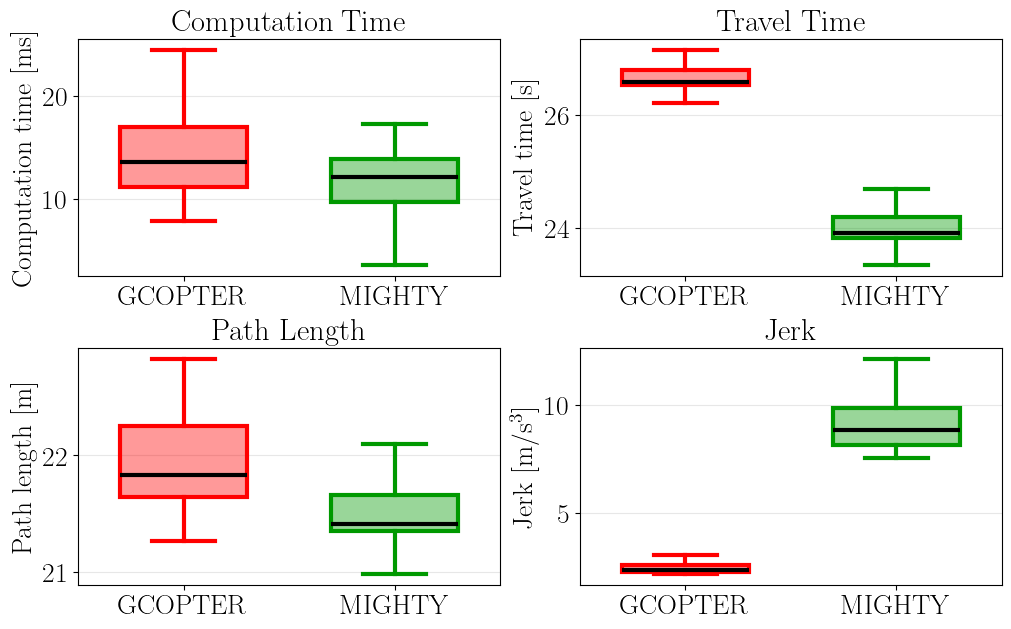

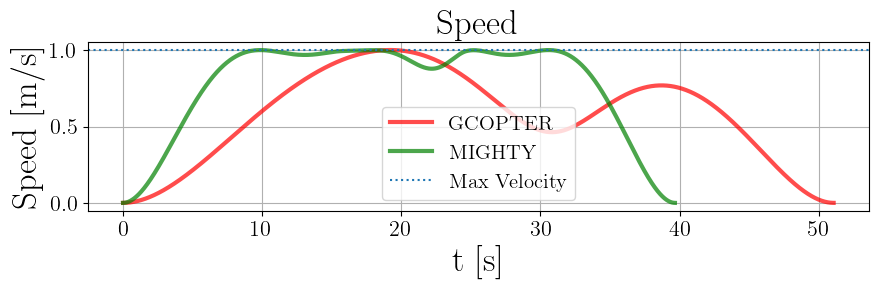

In [4]:
# One plot for simple benchmarking results

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Path to your aggregated CSV ===
# Change this to your actual file path:
CSV_PATH = ROOT_DIR / "analysis_summary" / "goal_summary.csv"   # e.g., "/media/kkondo/lucas_pro/mighty_gcopter_bench/goal_summary.csv"

# path to the paper figure output (optional)
FIG_OUTPUT_PATH = Path("/home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/simple_bench")

NUM_TOP_PERF = 20
NTH_BEST = 1  # for "typical" case

# === Load CSV (first row is header) ===
df = pd.read_csv(CSV_PATH)

if True:

    # We will index by Excel letters (0-based indices):
    # A=0, B=1, P=15, Q=16, R=17, S=18, V=21, W=22, X=23, Y=24
    col_idx = {
        "case": 0,     # A
        "goal": 1,     # B
        "gc_solve_ms": 15,  # P
        "gc_travel_s": 16,  # Q
        "gc_path_m":   17,  # R
        "gc_jerk":     18,  # S
        "mi_solve_ms": 21,  # V  (MIGHTY)
        "mi_travel_s": 22,  # W
        "mi_path_m":   23,  # X
        "mi_jerk":     24,  # Y
    }

    # Select and rename
    use = df.iloc[:, list(col_idx.values())].copy()
    use.columns = list(col_idx.keys())

    # Ensure numeric types (coerce errors to NaN)
    for k in ["gc_solve_ms","gc_travel_s","gc_path_m","gc_jerk",
            "mi_solve_ms","mi_travel_s","mi_path_m","mi_jerk"]:
        use[k] = pd.to_numeric(use[k], errors="coerce")

    # print("Rows loaded:", len(use))
    # print(use.head())
    def _two_box(ax, a, b, ylabel, title, labels=("GCOPTER","MIGHTY")):
        a = pd.to_numeric(a, errors="coerce").dropna().values
        b = pd.to_numeric(b, errors="coerce").dropna().values

        # Colors (fill colors with alpha); use opaque edges for crisp outlines
        gc_fill = (1.0, 0.0, 0.0, 0.4)   # red, alpha=0.7
        mi_fill = (0.0, 0.6, 0.0, 0.4)   # green, alpha=0.7
        gc_edge = (1.0, 0.0, 0.0, 1.0)
        mi_edge = (0.0, 0.6, 0.0, 1.0)
        lw = 3.0  # line width

        # GCOPTER box
        bp1 = ax.boxplot(
            a, positions=[1], widths=0.6, vert=True, patch_artist=True, showfliers=False,
            boxprops=dict(linewidth=lw, edgecolor=gc_edge),
            whiskerprops=dict(linewidth=lw, color=gc_edge),
            capprops=dict(linewidth=lw, color=gc_edge),
            medianprops=dict(linewidth=lw, color="black")
        )
        for patch in bp1["boxes"]:
            patch.set_facecolor(gc_fill)

        # MIGHTY box
        bp2 = ax.boxplot(
            b, positions=[2], widths=0.6, vert=True, patch_artist=True, showfliers=False,
            boxprops=dict(linewidth=lw, edgecolor=mi_edge),
            whiskerprops=dict(linewidth=lw, color=mi_edge),
            capprops=dict(linewidth=lw, color=mi_edge),
            medianprops=dict(linewidth=lw, color="black")
        )
        for patch in bp2["boxes"]:
            patch.set_facecolor(mi_fill)

        ax.set_xticks([1, 2], labels, fontsize=20)
        ax.set_ylabel(ylabel, fontsize=20)
        ax.tick_params(axis='y', labelsize=20)
        ax.set_title(title, fontsize=22)
        ax.grid(alpha=0.3, axis='y')

    # ---- build the 1x4 figure ----
    golden_ratio = (1.0 + math.sqrt(5.0)) / 2.0
    x_width = 10
    y_height = x_width / golden_ratio
    fig, axs = plt.subplots(2, 2, figsize=(x_width, y_height), constrained_layout=True)
    axs = axs.flatten()
    
    _two_box(axs[0],
            use["gc_solve_ms"], use["mi_solve_ms"],
            ylabel="Computation time [ms]", title="Computation Time")

    _two_box(axs[1],
            use["gc_travel_s"], use["mi_travel_s"],
            ylabel="Travel time [s]", title="Travel Time")

    _two_box(axs[2],
            use["gc_path_m"], use["mi_path_m"],
            ylabel="Path length [m]", title="Path Length")

    _two_box(axs[3],
            use["gc_jerk"], use["mi_jerk"],
            ylabel=r"Jerk [m/s$^3$]", title="Jerk")

    # save the figure 
    if FIG_OUTPUT_PATH.exists():
        fig_path = FIG_OUTPUT_PATH / f"simple_bench_{DATA_NUMBER}.pdf"
        plt.savefig(fig_path, dpi=300)
        print(f"[ok] Saved figure to {fig_path}")
    else:
        plt.show()

    # ---------- load & slice by Excel-letter indices ----------
    # A=0, B=1, Q=16 (GC travel s), W=22 (MINCO travel s) -- MIGHTY travel s not given by letter, so we'll check by name later.
    df_full = pd.read_csv(CSV_PATH)


    # Build a small working frame using the letters you specified
    use = pd.DataFrame({
        "case": df_full.iloc[:, 0],   # A
        "goal": df_full.iloc[:, 1],   # B
        "gc_travel_s": pd.to_numeric(df_full.iloc[:, 16], errors="coerce"),  # Q
    })

    # Try to locate MIGHTY travel time column by common names first; else fall back to MINCO (W=22)
    # If your summary actually stores MIGHTY under a named column, add it here:
    known_mighty_names = ["my_travel_s", "mighty_travel_s", "mighty_time_s", "mighty_traj_time"]
    mighty_col = next((c for c in df_full.columns if c in known_mighty_names), None)

    if mighty_col is not None:
        OTHER_LABEL = "MIGHTY"
        use["other_travel_s"] = pd.to_numeric(df_full[mighty_col], errors="coerce")
    else:
        # Fall back to MINCO (W column index 22)
        OTHER_LABEL = "MINCO"
        use["other_travel_s"] = pd.to_numeric(df_full.iloc[:, 22], errors="coerce")  # W

    print(f"Comparing GCOPTER vs {OTHER_LABEL}")

    # ---------- compute delta and find best ----------
    use = use.dropna(subset=["gc_travel_s","other_travel_s"]).copy()
    use["delta_s"] = use["gc_travel_s"] - use["other_travel_s"]  # positive => OTHER is faster than GCOPTER

    # Best (case, goal) row where OTHER beats GCOPTER
    faster = use[use["delta_s"] > 0]
    if faster.empty:
        print("No rows where OTHER (MIGHTY/MINCO) is faster than GCOPTER.")
    else:
        best_row = faster.sort_values("delta_s", ascending=False).iloc[0]
        print("\nBest single run (largest GCOPTER - OTHER travel-time gap):")
        print(f"  case: {best_row['case']}")
        print(f"  goal: {best_row['goal']}")
        print(f"  GCOPTER travel: {best_row['gc_travel_s']:.3f} s")
        print(f"  {OTHER_LABEL} travel: {best_row['other_travel_s']:.3f} s")
        print(f"  Δ travel time (GC - {OTHER_LABEL}): {best_row['delta_s']:.3f} s (positive => {OTHER_LABEL} faster)")

        # Also identify which *case* is best when aggregating by MAX improvement within that case
        per_case = faster.groupby("case", as_index=False)["delta_s"].max().sort_values("delta_s", ascending=False)
        best_case = per_case.iloc[0]
        print("\nBest CASE by max improvement over its goals:")
        print(f"  case: {best_case['case']}")
        print(f"  max Δ travel time (GC - {OTHER_LABEL}): {best_case['delta_s']:.3f} s")

        # (Optional) show top 5 rows for sanity
        print("\nTop 5 single runs by improvement:")
        display(faster.sort_values("delta_s", ascending=False).head(10))

        # Get the best case's path
        best_case_goals = ROOT_DIR_STR + "/" + best_case['case'] + "/" + faster.sort_values("delta_s", ascending=False).head(NUM_TOP_PERF)['goal'].values[NTH_BEST - 1]
        print(f"\nBest case path: {best_case_goals}")
        save_path = FIG_OUTPUT_PATH / f"example_nth_best{NTH_BEST}_data{DATA_NUMBER}.pdf"
        print(f"save path: {save_path}")
        # plot_history(best_case_goals, max_vel=max_vel, save_path=save_path)
        plot_vel_history(best_case_goals, max_vel=max_vel, save_path=save_path)


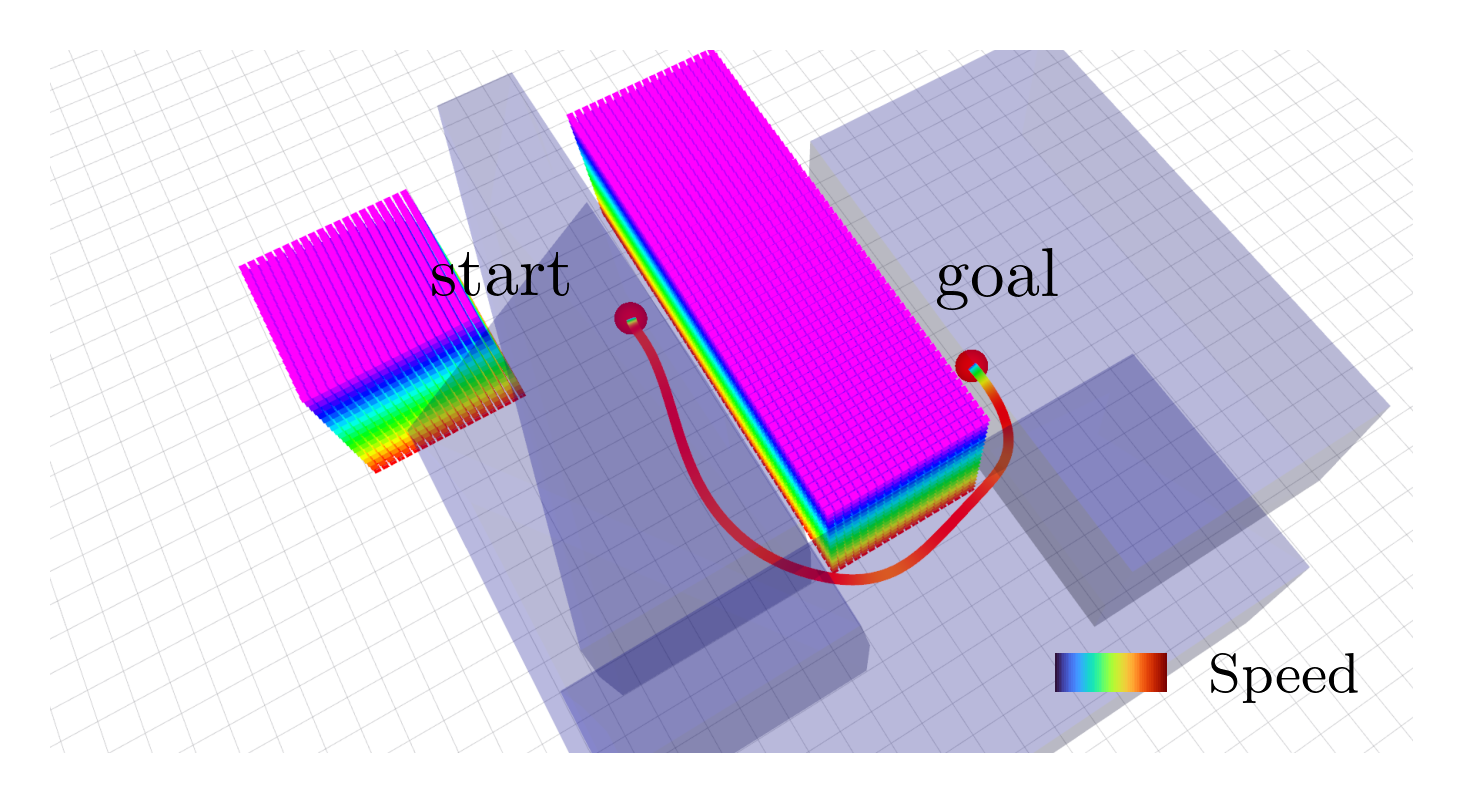

In [12]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

class _GradientLegend:
    """A dummy handle that carries a colormap + orientation for the legend."""
    def __init__(self, cmap='turbo', orientation='horizontal', n=64):
        self.cmap = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
        self.orientation = orientation  # 'horizontal' or 'vertical'
        self.n = int(n)

class _HandlerGradient(HandlerBase):
    """Draws a gradient rectangle inside the legend handle box."""
    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        n = max(2, orig_handle.n)
        cmap = orig_handle.cmap
        orient = orig_handle.orientation
        artists = []
        if orient == 'horizontal':
            w = width / n
            for i in range(n):
                color = cmap(i / (n - 1))
                artists.append(Rectangle((xdescent + i * w, ydescent),
                                         w, height, transform=trans,
                                         facecolor=color, edgecolor='none'))
        else:
            h = height / n
            for i in range(n):
                color = cmap(i / (n - 1))
                artists.append(Rectangle((xdescent, ydescent + i * h),
                                         width, h, transform=trans,
                                         facecolor=color, edgecolor='none'))
        return artists


def trim_add_legend_save(
    img_input,
    out_path,
    cut=(0, 0, 0, 0),            # (left, bottom, right, top) pixels to remove
    legend_items=None,           # e.g., [("GCOPTER","cornflowerblue"), ("MIGHTY","lime")]
    legend_loc="lower right",
    legend_title=None,
    legend_box=False,            # False = no frame around legend box
    figsize=None,
    dpi=300,
    hide_axes=True,
    show=False,
    # --- text annotations ---
    start_text=None,             # e.g., "start"
    start_pos=None,              # (x,y) axes-fraction if pos_mode='axes' (default), else pixels if 'pixel'
    goal_text=None,              # e.g., "goal"
    goal_pos=None,               # (x,y)
    pos_mode="axes",             # 'axes' (0..1 fractions) or 'pixel' (cropped image pixels)
    text_kwargs=None             # shared style dict for both labels
):
    """
    Crop an image, add a legend (no black swatch borders), overlay 'start'/'goal' text, and save as PNG.

    img_input : str | Path | np.ndarray | PIL.Image.Image
    out_path  : str | Path
    cut       : (left, bottom, right, top) pixels to remove from each side
    legend_items : list[(label, color)]
    legend_box : if True, keep legend frame; if False, remove
    pos_mode  : 'axes' -> positions in [0..1] fractions of axes; 'pixel' -> cropped-image pixels (x from left, y from top)
    start_pos / goal_pos : tuples interpreted based on pos_mode
    text_kwargs : e.g., {'fontsize': 16, 'color': 'white', 'weight': 'bold',
                         'bbox': dict(facecolor='black', alpha=0.4, edgecolor='none', boxstyle='round,pad=0.2')}
    Returns: (fig, ax, (ymin, ymax, xmin, xmax)) of the crop box in original pixel coords.
    """
    # ---- Load to RGBA ----
    if isinstance(img_input, (str, Path)):
        im = Image.open(img_input).convert("RGBA")
    elif isinstance(img_input, Image.Image):
        im = img_input.convert("RGBA")
    elif isinstance(img_input, np.ndarray):
        arr = img_input
        if arr.ndim == 2:
            im = Image.fromarray(arr.astype(np.uint8), mode="L").convert("RGBA")
        elif arr.ndim == 3:
            if arr.dtype != np.uint8:
                arr = arr.astype(np.uint8)
            if arr.shape[2] == 4:
                im = Image.fromarray(arr, mode="RGBA")
            elif arr.shape[2] == 3:
                im = Image.fromarray(arr, mode="RGB").convert("RGBA")
            else:
                raise ValueError("Unsupported array shape; expected HxW, HxWx3, or HxWx4.")
        else:
            raise ValueError("Unsupported array shape; expected 2D or 3D.")
    else:
        raise ValueError("img_input must be a path, PIL.Image, or numpy array.")

    arr = np.asarray(im)  # H x W x 4
    H, W = arr.shape[0], arr.shape[1]

    # ---- Validate & compute crop box ----
    try:
        left, bottom, right, top = [int(round(v)) for v in cut]
    except Exception:
        raise ValueError("cut must be a 4-tuple of ints (left, bottom, right, top).")

    left   = max(0, left)
    right  = max(0, right)
    top    = max(0, top)
    bottom = max(0, bottom)

    x0 = left
    x1 = W - right
    y0 = top
    y1 = H - bottom

    if x0 >= x1 or y0 >= y1:
        raise ValueError(
            f"Crop exceeds image size: image {(W, H)}, requested cut {cut} -> box {(x0, y0, x1, y1)}"
        )

    cropped = arr[y0:y1, x0:x1, :]
    ch, cw = cropped.shape[:2]

    # ---- Plot & legend ----
    if figsize is None:
        figsize = (cw / dpi, ch / dpi)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.imshow(cropped)
    if hide_axes:
        ax.axis("off")

    if legend_items:
        handles, labels = [], []
        handler_map = {}

        for (lbl, c) in legend_items:
            # Accept ("Speed", "rainbow") or ("Speed", "cmap:turbo")
            if isinstance(c, str) and (c == "rainbow" or c.startswith("cmap:")):
                cmap_name = "turbo" if c == "rainbow" else c.split(":", 1)[1]
                h = _GradientLegend(cmap=cmap_name, orientation="horizontal", n=64)
                handles.append(h); labels.append(lbl)
                handler_map[_GradientLegend] = _HandlerGradient()

            # Or a dict form: {"cmap":"turbo","orientation":"vertical","n":64}
            elif isinstance(c, dict) and "cmap" in c:
                h = _GradientLegend(cmap=c["cmap"],
                                    orientation=c.get("orientation", "horizontal"),
                                    n=c.get("n", 64))
                handles.append(h); labels.append(lbl)
                handler_map[_GradientLegend] = _HandlerGradient()

            # Fallback: solid color patch (old behavior)
            else:
                handles.append(Patch(facecolor=c, edgecolor="none"))
                labels.append(lbl)

        leg = ax.legend(handles=handles, labels=labels,
                        loc=legend_loc, title=legend_title,
                        frameon=legend_box, fontsize=8,
                        handler_map=handler_map)
        if legend_box and leg is not None:
            leg.get_frame().set_alpha(0.85)


    # ---- Text annotations ----
    if text_kwargs is None:
        text_kwargs = dict(
            fontsize=10, color="black", weight="bold"
        )

    def _put_text(txt, pos):
        if txt is None or pos is None:
            return
        if pos_mode == "axes":
            ax.text(pos[0], pos[1], txt, transform=ax.transAxes, **text_kwargs)
        elif pos_mode == "pixel":
            # Data coords match image pixels (origin at top-left for imshow), so this is fine:
            ax.text(pos[0], pos[1], txt, **text_kwargs)
        else:
            raise ValueError("pos_mode must be 'axes' or 'pixel'.")

    _put_text(start_text, start_pos)
    _put_text(goal_text, goal_pos)

    # ---- Save ----
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight", pad_inches=0.0)
    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax, (int(y0), int(y1), int(x0), int(x1))


# Trim white-ish border (auto), add legend, save
_ = trim_add_legend_save(
    img_input="/home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/simple_bench/simple_bench_data2_goal090.png",
    out_path="/home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/simple_bench/paper_ready_simple_bench_data2_goal090.png",
    cut=(800, 300, 800, 200),
    legend_items=[("Speed","rainbow")],
    legend_loc="lower right",
    legend_title="",
    legend_box=False,  # no frame around legend box
    dpi=500,
    hide_axes=True,
    show=True,
    # Add labels (axes-fraction positions)
    start_text="start", start_pos=(0.28, 0.65),  # near top-left
    goal_text="goal",   goal_pos=(0.65, 0.65),   # near top-right
    pos_mode="axes"
)

In [13]:
# Drop-in analysis cell for GCOPTER/MIGHTY sweep results
# - Scans case_* / goal_* directories
# - Reads bench_stats.csv for performance + collisions
# - Reads gcopter_vaj.csv / mighty_vaj.csv to count dynamic-constraint violations
# - Produces two CSVs: case_summary.csv and goal_summary.csv under <ROOT_DIR>/analysis_summary
# - Displays both tables

import os, re, math, json
from pathlib import Path
import pandas as pd
import numpy as np

# ============================== User-config ==============================
# Root directory that contains case_* folders:
DATA_NUMBER = 4
ROOT_DIR = Path(f"/media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/data{DATA_NUMBER}")
# ROOT_DIR = Path(f"/media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/")

# Allowed relative violation (e.g., 0.01 = 1%, 0.02 = 2%)
ALLOW_VIOL_PCT = 0.01  # change to 0.02 if you allow 2%

# Dynamic limits (used for body-rate / tilt / thrust). Velocity limit is read per goal from bench_stats.csv:max_vel.
# Set these to match your run; defaults mirror typical values in your node.
MAX_BODYRATE = 2.1           # rad/s
MAX_TILT_RAD = 1.05          # rad
THRUST_MIN   = 2.0           # N
THRUST_MAX   = 12.0          # N

# Where to write the summaries
OUT_DIR = ROOT_DIR / "analysis_summary"
OUT_DIR.mkdir(parents=True, exist_ok=True)
# ========================================================================

if True:

    PLANNERS = ("gc", "my")  # "gc" = GCOPTER, "my" = MIGHTY
    VAJ_FILENAMES = {"gc": "gcopter_vaj.csv", "my": "mighty_vaj.csv"}

    def _read_bench_stats(csv_path: Path):
        """
        Read bench_stats.csv and return the last row as a dict (robust to multiple appends).
        Expected columns (from appendStatsCSV in minco_bench_viz.cpp):
        stamp,start_x,start_y,start_z,goal_x,goal_y,goal_z,
        max_vel,jerk_weight,sfc_progress,sfc_range,sample_dt,collision_dt,
        gc_solve_ms,gc_time_s,gc_path_len,gc_jerk_cost,gc_collisions,
        my_solve_ms,my_time_s,my_path_len,my_jerk_cost,my_collisions
        """
        if not csv_path.exists():
            return None
        try:
            df = pd.read_csv(csv_path)
        except Exception:
            return None
        if df.empty:
            return None
        # take the last non-NA row (some runs might append more than once)
        row = df.dropna(how="all").iloc[-1].to_dict()
        # Normalize keys -> simple strings
        return {str(k).strip(): row[k] for k in row}

    def _read_vaj(csv_path: Path):
        """
        Read vaj CSV and return minimal dataframe with needed columns.
        Expected columns from writer:
        v_norm, omega_norm, tilt, thrust
        """
        if not csv_path.exists():
            return None
        usecols = ["v_norm", "omega_norm", "tilt", "thrust"]
        try:
            df = pd.read_csv(csv_path, usecols=usecols)
        except Exception:
            # Try without usecols if schema changed, then filter
            try:
                df = pd.read_csv(csv_path)
                missing = [c for c in usecols if c not in df.columns]
                if missing:
                    return None
                df = df[usecols]
            except Exception:
                return None
        # ensure numeric
        for c in usecols:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        return df.dropna()

    def _dyn_viols(df_vaj: pd.DataFrame, vel_max: float,
                bdr_max=MAX_BODYRATE, tilt_max=MAX_TILT_RAD,
                thr_min=THRUST_MIN, thr_max=THRUST_MAX,
                tol=ALLOW_VIOL_PCT):
        """
        Count dynamic violations with tolerance 'tol'.
        - vel violation if v_norm > vel_max * (1 + tol)
        - body-rate violation if omega_norm > bdr_max * (1 + tol)
        - tilt violation if tilt > tilt_max * (1 + tol)
        - thrust violation if thrust < thr_min*(1 - tol) or > thr_max*(1 + tol)
        Returns dict with counts, fractions, and 'any' flags.
        """
        if df_vaj is None or df_vaj.empty or not np.isfinite(vel_max):
            # nothing to check
            return {
                "vel_count": np.nan, "vel_frac": np.nan, "vel_any": np.nan,
                "bdr_count": np.nan, "bdr_frac": np.nan, "bdr_any": np.nan,
                "tilt_count": np.nan, "tilt_frac": np.nan, "tilt_any": np.nan,
                "thr_count": np.nan, "thr_frac": np.nan, "thr_any": np.nan,
            }

        n = len(df_vaj)
        vel_count  = int((df_vaj["v_norm"]      > vel_max * (1.0 + tol)).sum())
        bdr_count  = int((df_vaj["omega_norm"]  > bdr_max * (1.0 + tol)).sum())
        tilt_count = int((df_vaj["tilt"]        > tilt_max * (1.0 + tol)).sum())
        thr_count  = int(((df_vaj["thrust"]     < thr_min * (1.0 - tol)) |
                        (df_vaj["thrust"]     > thr_max * (1.0 + tol))).sum())

        def frac(c): 
            return (c / n) if n > 0 else np.nan

        return {
            "vel_count": vel_count,   "vel_frac": frac(vel_count),   "vel_any": bool(vel_count > 0),
            "bdr_count": bdr_count,   "bdr_frac": frac(bdr_count),   "bdr_any": bool(bdr_count > 0),
            "tilt_count": tilt_count, "tilt_frac": frac(tilt_count), "tilt_any": bool(tilt_count > 0),
            "thr_count": thr_count,   "thr_frac": frac(thr_count),   "thr_any": bool(thr_count > 0),
        }

    def _parse_case_tokens(case_dir_name: str):
        """
        Attempt to parse case name like 'case_0000_v1.00_jw1e_3'.
        Returns dict with case_idx, v_s, jw_s if found (strings); else None values.
        """
        m = re.match(r"^case_(\d+)_v([0-9.]+)_jw(.+)$", case_dir_name)
        if not m:
            m = re.match(r"^case_(\d+).*$", case_dir_name)
            if m:
                return {"case_idx": int(m.group(1)), "v_s": None, "jw_s": None}
            return {"case_idx": None, "v_s": None, "jw_s": None}
        return {"case_idx": int(m.group(1)), "v_s": m.group(2), "jw_s": m.group(3)}

    goal_rows = []

    case_dirs = sorted([p for p in ROOT_DIR.iterdir() if p.is_dir() and p.name.startswith("case_")])
    if not case_dirs:
        print(f"[warn] No 'case_*' directories found under {ROOT_DIR}")

    for case_dir in case_dirs:
        tokens = _parse_case_tokens(case_dir.name)
        goal_dirs = sorted([g for g in case_dir.iterdir() if g.is_dir() and g.name.startswith("goal_")])
        if not goal_dirs:
            # also allow files like goal_000 exists but not a directory (unlikely)
            continue

        for gdir in goal_dirs:
            # bench stats
            bs = _read_bench_stats(gdir / "bench_stats.csv")
            if bs is None:
                # Missing or unreadable stats -> skip this goal
                continue

            # Pull shared info
            max_vel = float(bs.get("max_vel", np.nan))
            jerk_w  = bs.get("jerk_weight", np.nan)
            goal_xyz = tuple(float(bs.get(k, np.nan)) for k in ("goal_x","goal_y","goal_z"))
            start_xyz = tuple(float(bs.get(k, np.nan)) for k in ("start_x","start_y","start_z"))

            # GCOPTER metrics from bench_stats
            gc = {
                "solve_ms": float(bs.get("gc_solve_ms", np.nan)),
                "time_s":   float(bs.get("gc_time_s", np.nan)),
                "path_len": float(bs.get("gc_path_len", np.nan)),
                "jerk":     float(bs.get("gc_jerk_cost", np.nan)),
                "collisions": int(bs.get("gc_collisions", np.nan)) if pd.notna(bs.get("gc_collisions", np.nan)) else np.nan,
            }
            # MIGHTY metrics
            my = {
                "solve_ms": float(bs.get("my_solve_ms", np.nan)),
                "time_s":   float(bs.get("my_time_s", np.nan)),
                "path_len": float(bs.get("my_path_len", np.nan)),
                "jerk":     float(bs.get("my_jerk_cost", np.nan)),
                "collisions": int(bs.get("my_collisions", np.nan)) if pd.notna(bs.get("my_collisions", np.nan)) else np.nan,
            }

            # Dynamic violation counts from vaj CSVs
            df_gc_vaj = _read_vaj(gdir / VAJ_FILENAMES["gc"])
            df_my_vaj = _read_vaj(gdir / VAJ_FILENAMES["my"])
            dyn_gc = _dyn_viols(df_gc_vaj, vel_max=max_vel)
            dyn_my = _dyn_viols(df_my_vaj, vel_max=max_vel)

            row = {
                "case": case_dir.name,
                "goal": gdir.name,
                "start_x": start_xyz[0], "start_y": start_xyz[1], "start_z": start_xyz[2],
                "goal_x": goal_xyz[0],   "goal_y": goal_xyz[1],   "goal_z": goal_xyz[2],
                "max_vel": max_vel,
                "jerk_weight": jerk_w,
                "allow_violation_pct": ALLOW_VIOL_PCT,
                "bdr_limit": MAX_BODYRATE,
                "tilt_limit_rad": MAX_TILT_RAD,
                "thrust_min": THRUST_MIN,
                "thrust_max": THRUST_MAX,

                # GCOPTER performance
                "gc_solve_ms": gc["solve_ms"],
                "gc_time_s": gc["time_s"],
                "gc_path_len": gc["path_len"],
                "gc_jerk": gc["jerk"],
                "gc_collisions": gc["collisions"],
                "gc_collision_any": (gc["collisions"] > 0) if pd.notna(gc["collisions"]) else np.nan,

                # MIGHTY performance
                "my_solve_ms": my["solve_ms"],
                "my_time_s": my["time_s"],
                "my_path_len": my["path_len"],
                "my_jerk": my["jerk"],
                "my_collisions": my["collisions"],
                "my_collision_any": (my["collisions"] > 0) if pd.notna(my["collisions"]) else np.nan,

                # GCOPTER dynamics (counts, fractions, any)
                "gc_viol_vel_count": dyn_gc["vel_count"],
                "gc_viol_vel_frac": dyn_gc["vel_frac"],
                "gc_viol_vel_any":  dyn_gc["vel_any"],

                "gc_viol_bdr_count": dyn_gc["bdr_count"],
                "gc_viol_bdr_frac": dyn_gc["bdr_frac"],
                "gc_viol_bdr_any":  dyn_gc["bdr_any"],

                "gc_viol_tilt_count": dyn_gc["tilt_count"],
                "gc_viol_tilt_frac": dyn_gc["tilt_frac"],
                "gc_viol_tilt_any":  dyn_gc["tilt_any"],

                "gc_viol_thr_count": dyn_gc["thr_count"],
                "gc_viol_thr_frac": dyn_gc["thr_frac"],
                "gc_viol_thr_any":  dyn_gc["thr_any"],

                # MIGHTY dynamics (counts, fractions, any)
                "my_viol_vel_count": dyn_my["vel_count"],
                "my_viol_vel_frac": dyn_my["vel_frac"],
                "my_viol_vel_any":  dyn_my["vel_any"],

                "my_viol_bdr_count": dyn_my["bdr_count"],
                "my_viol_bdr_frac": dyn_my["bdr_frac"],
                "my_viol_bdr_any":  dyn_my["bdr_any"],

                "my_viol_tilt_count": dyn_my["tilt_count"],
                "my_viol_tilt_frac": dyn_my["tilt_frac"],
                "my_viol_tilt_any":  dyn_my["tilt_any"],

                "my_viol_thr_count": dyn_my["thr_count"],
                "my_viol_thr_frac": dyn_my["thr_frac"],
                "my_viol_thr_any":  dyn_my["thr_any"],
            }

            # Optional: record parsed tokens from case name
            row.update(_parse_case_tokens(case_dir.name))
            goal_rows.append(row)

    # Assemble per-goal table
    if goal_rows:
        df_goals = pd.DataFrame(goal_rows)

        # ---- Per-case summary ----
        def pct_mean(s):
            # percentage of True among non-null booleans
            s = s.dropna()
            if s.empty:
                return np.nan
            # s may contain bool or object; coerce
            return 100.0 * (pd.Series(s, dtype="bool").mean())

        agg_spec = {
            # performance means
            "gc_solve_ms": "mean", "gc_time_s": "mean", "gc_path_len": "mean", "gc_jerk": "mean",
            "my_solve_ms": "mean", "my_time_s": "mean", "my_path_len": "mean", "my_jerk": "mean",
            # collision percentages
            "gc_collision_any": pct_mean,
            "my_collision_any": pct_mean,
            # dynamic violation goal % (a goal counts as violating if any sample violated)
            "gc_viol_vel_any": pct_mean, "gc_viol_bdr_any": pct_mean, "gc_viol_tilt_any": pct_mean, "gc_viol_thr_any": pct_mean,
            "my_viol_vel_any": pct_mean, "my_viol_bdr_any": pct_mean, "my_viol_tilt_any": pct_mean, "my_viol_thr_any": pct_mean,
            # capture typical limits used
            "max_vel": "median",
            "bdr_limit": "median",
            "tilt_limit_rad": "median",
            "thrust_min": "median",
            "thrust_max": "median",
            "allow_violation_pct": "median",
        }

        df_case_summary = df_goals.groupby("case", as_index=False).agg(agg_spec)

        # rename some columns to be explicit (percentages)
        df_case_summary = df_case_summary.rename(columns={
            "gc_collision_any": "gc_pct_goals_with_collision",
            "my_collision_any": "my_pct_goals_with_collision",
            "gc_viol_vel_any": "gc_pct_goals_viol_vel",
            "gc_viol_bdr_any": "gc_pct_goals_viol_bodyrate",
            "gc_viol_tilt_any": "gc_pct_goals_viol_tilt",
            "gc_viol_thr_any": "gc_pct_goals_viol_thrust",
            "my_viol_vel_any": "my_pct_goals_viol_vel",
            "my_viol_bdr_any": "my_pct_goals_viol_bodyrate",
            "my_viol_tilt_any": "my_pct_goals_viol_tilt",
            "my_viol_thr_any": "my_pct_goals_viol_thrust",
        })

        # add counts
        counts = df_goals.groupby("case").size().rename("n_goals").reset_index()
        df_case_summary = df_case_summary.merge(counts, on="case", how="left")

        # Friendly ordering
        cols_order = [
            "case", "n_goals",
            "allow_violation_pct",
            "max_vel","bdr_limit","tilt_limit_rad","thrust_min","thrust_max",
            "gc_solve_ms","gc_time_s","gc_path_len","gc_jerk",
            "my_solve_ms","my_time_s","my_path_len","my_jerk",
            "gc_pct_goals_with_collision","my_pct_goals_with_collision",
            "gc_pct_goals_viol_vel","gc_pct_goals_viol_bodyrate","gc_pct_goals_viol_tilt","gc_pct_goals_viol_thrust",
            "my_pct_goals_viol_vel","my_pct_goals_viol_bodyrate","my_pct_goals_viol_tilt","my_pct_goals_viol_thrust",
        ]
        df_case_summary = df_case_summary.reindex(columns=cols_order)

        # Round for readability
        df_case_summary = df_case_summary.round({
            "allow_violation_pct": 4,
            "max_vel": 3, "bdr_limit": 3, "tilt_limit_rad": 3, "thrust_min": 3, "thrust_max": 3,
            "gc_solve_ms": 3, "gc_time_s": 3, "gc_path_len": 3, "gc_jerk": 3,
            "my_solve_ms": 3, "my_time_s": 3, "my_path_len": 3, "my_jerk": 3,
            "gc_pct_goals_with_collision": 2, "my_pct_goals_with_collision": 2,
            "gc_pct_goals_viol_vel": 2, "gc_pct_goals_viol_bodyrate": 2, "gc_pct_goals_viol_tilt": 2, "gc_pct_goals_viol_thrust": 2,
            "my_pct_goals_viol_vel": 2, "my_pct_goals_viol_bodyrate": 2, "my_pct_goals_viol_tilt": 2, "my_pct_goals_viol_thrust": 2,
        })

        # Write CSVs
        case_csv = OUT_DIR / "case_summary.csv"
        goal_csv = OUT_DIR / "goal_summary.csv"
        df_case_summary.to_csv(case_csv, index=False)
        df_goals.to_csv(goal_csv, index=False)

        print(f"[ok] Wrote {case_csv}")
        print(f"[ok] Wrote {goal_csv}")

        # Show tables inline if running in a notebook
        try:
            # If ace_tools is available in your Jupyter, display as interactive tables.
            import ace_tools as tools; from ace_tools import display_dataframe_to_user
            display_dataframe_to_user("Case Summary (averages & percentages)", df_case_summary)
            display_dataframe_to_user("Per-Goal Details", df_goals)
        except Exception:
            # Fallback: print first few rows
            print("\nCase Summary:")
            display(df_case_summary.head())
            print("\nPer-Goal Details:")
            display(df_goals.head())

    else:
        print("[warn] No goals parsed; check ROOT_DIR or file layout.")


[ok] Wrote /media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/data4/analysis_summary/case_summary.csv
[ok] Wrote /media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/data4/analysis_summary/goal_summary.csv

Case Summary:


,case,n_goals,allow_violation_pct,max_vel,bdr_limit,tilt_limit_rad,thrust_min,thrust_max,gc_solve_ms,gc_time_s,...,gc_pct_goals_with_collision,my_pct_goals_with_collision,gc_pct_goals_viol_vel,gc_pct_goals_viol_bodyrate,gc_pct_goals_viol_tilt,gc_pct_goals_viol_thrust,my_pct_goals_viol_vel,my_pct_goals_viol_bodyrate,my_pct_goals_viol_tilt,my_pct_goals_viol_thrust
0,case_00000_v1.00_jw1e-3,24,0.01,1.0,2.1,1.05,2.0,12.0,12.408,25.012,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,case_00024_v2.00_jw1e-3,24,0.01,2.0,2.1,1.05,2.0,12.0,8.066,13.359,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,case_00048_v3.00_jw1e-3,24,0.01,3.0,2.1,1.05,2.0,12.0,5.861,8.674,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,case_00072_v4.00_jw1e-3,24,0.01,4.0,2.1,1.05,2.0,12.0,7.755,6.817,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,case_00096_v5.00_jw1e-3,24,0.01,5.0,2.1,1.05,2.0,12.0,7.046,6.085,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Per-Goal Details:


,case,goal,start_x,start_y,start_z,goal_x,goal_y,goal_z,max_vel,jerk_weight,...,my_viol_bdr_any,my_viol_tilt_count,my_viol_tilt_frac,my_viol_tilt_any,my_viol_thr_count,my_viol_thr_frac,my_viol_thr_any,case_idx,v_s,jw_s
0,case_00000_v1.00_jw1e-3,goal_000,0.0,0.0,0.5,-15.0,-15.0,2.5,1.0,0.00001,...,False,0,0.0,False,0,0.0,False,0,1.00,1e-3
1,case_00000_v1.00_jw1e-3,goal_001,0.0,0.0,0.5,-15.0,-10.0,2.5,1.0,0.00001,...,False,0,0.0,False,0,0.0,False,0,1.00,1e-3
2,case_00000_v1.00_jw1e-3,goal_002,0.0,0.0,0.5,-15.0,-5.0,2.5,1.0,0.00001,...,False,0,0.0,False,0,0.0,False,0,1.00,1e-3
3,case_00000_v1.00_jw1e-3,goal_003,0.0,0.0,0.5,-15.0,0.0,2.5,1.0,0.00001,...,False,0,0.0,False,0,0.0,False,0,1.00,1e-3
4,case_00000_v1.00_jw1e-3,goal_004,0.0,0.0,0.5,-15.0,5.0,2.5,1.0,0.00001,...,False,0,0.0,False,0,0.0,False,0,1.00,1e-3


[ok] Wrote /media/kkondo/T7/mighty_gcopter_bench/simple_bench/analysis_simple_sweep/mighty_simple_sweep_avg.csv
[ok] Wrote /media/kkondo/T7/mighty_gcopter_bench/simple_bench/analysis_simple_sweep/gcopter_ref_avg.csv
[ok] Wrote /media/kkondo/T7/mighty_gcopter_bench/simple_bench/analysis_simple_sweep/simple_sweep_metrics.pdf


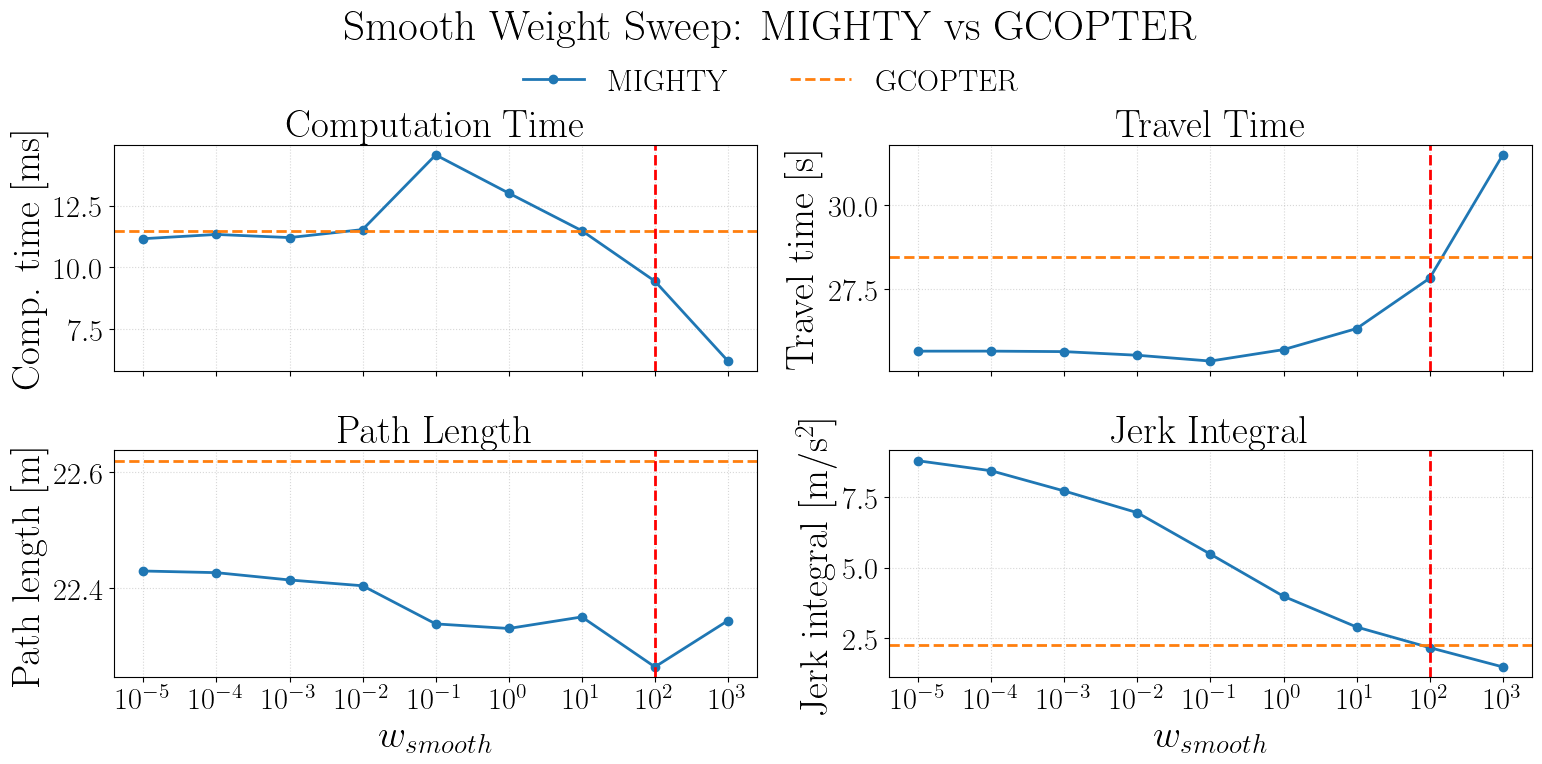

,weight_str,weight_val,my_solve_ms,my_time_s,my_path_len,my_jerk,my_collisions,n_goals,max_vel
0,1e-5,0.00001,11.16860,25.650360,22.429425,8.799663,0.0,100,1.0
1,1e-4,0.00010,11.34119,25.651343,22.426568,8.444958,0.0,100,1.0
2,1e-3,0.00100,11.21355,25.636683,22.413912,7.726415,0.0,100,1.0
3,1e-2,0.01000,11.53818,25.528392,22.403895,6.954984,0.0,100,1.0
4,1e-1,0.10000,14.56960,25.355151,22.337918,5.482244,0.0,100,1.0
5,1e+0,1.00000,13.01829,25.696369,22.329975,3.986088,0.0,100,1.0
6,1e+1,10.00000,11.49346,26.324225,22.349950,2.894887,0.0,100,1.0
7,1e+2,100.00000,9.44330,27.825437,22.263454,2.162217,0.0,100,1.0
8,1e+3,1000.00000,6.20040,31.501867,22.343615,1.477412,0.0,100,1.0


,gc_ref_weight,n_goals,gc_solve_ms,gc_time_s,gc_path_len,gc_jerk,gc_collisions,max_vel
0,1e-5,100,11.46306,28.46015,22.620173,2.251637,0.0,1.0


In [52]:
# Analyze simple sweep (with different jerk cost in mighty) benchmark results
# Layout: /media/kkondo/T7/mighty_gcopter_bench/simple_bench/weight_1e-1/goal_000
# Produces per-weight averages for MIGHTY, and GCOPTER averages from a reference weight.

import re
from pathlib import Path
import pandas as pd
import numpy as np

# ============================== User-config ==============================
SIMPLE_ROOT = Path("/media/kkondo/T7/mighty_gcopter_bench/simple_bench")
GC_REF_WEIGHT = "1e-5"  # use this weight's GCOPTER results as reference
OUT_DIR = SIMPLE_ROOT / "analysis_simple_sweep"
OUT_DIR.mkdir(parents=True, exist_ok=True)
# ========================================================================

def _read_bench_stats(csv_path: Path):
    if not csv_path.exists():
        return None
    try:
        df = pd.read_csv(csv_path)
    except Exception:
        return None
    if df.empty:
        return None
    row = df.dropna(how="all").iloc[-1].to_dict()
    return {str(k).strip(): row[k] for k in row}

def _parse_weight_dir(name: str):
    # expected: weight_1e-3
    if not name.startswith("weight_"):
        return None
    w_str = name[len("weight_"):]
    try:
        w_val = float(w_str)
    except Exception:
        # try to normalize 1e-05 style
        try:
            w_val = float(w_str.replace("e", "E"))
        except Exception:
            return None
    return w_str, w_val

rows = []
weight_dirs = sorted([d for d in SIMPLE_ROOT.iterdir() if d.is_dir() and d.name.startswith("weight_")])
if not weight_dirs:
    print(f"[warn] No weight_* directories found under {SIMPLE_ROOT}")

for wdir in weight_dirs:
    parsed = _parse_weight_dir(wdir.name)
    if not parsed:
        continue
    w_str, w_val = parsed

    goal_dirs = sorted([g for g in wdir.iterdir() if g.is_dir() and g.name.startswith("goal_")])
    if not goal_dirs:
        continue

    for gdir in goal_dirs:
        bs = _read_bench_stats(gdir / "bench_stats.csv")
        if bs is None:
            continue

        rows.append({
            "weight_str": w_str,
            "weight_val": w_val,
            "goal": gdir.name,
            "max_vel": float(bs.get("max_vel", np.nan)),

            # GCOPTER metrics
            "gc_solve_ms": float(bs.get("gc_solve_ms", np.nan)),
            "gc_time_s": float(bs.get("gc_time_s", np.nan)),
            "gc_path_len": float(bs.get("gc_path_len", np.nan)),
            "gc_jerk": float(bs.get("gc_jerk_cost", np.nan)),
            "gc_collisions": float(bs.get("gc_collisions", np.nan)),

            # MIGHTY metrics
            "my_solve_ms": float(bs.get("my_solve_ms", np.nan)),
            "my_time_s": float(bs.get("my_time_s", np.nan)),
            "my_path_len": float(bs.get("my_path_len", np.nan)),
            "my_jerk": float(bs.get("my_jerk_cost", np.nan)),
            "my_collisions": float(bs.get("my_collisions", np.nan)),
        })

if not rows:
    print("[warn] No bench_stats.csv files found. Check SIMPLE_ROOT and paths.")
else:
    df = pd.DataFrame(rows)

    # Per-weight averages (MIGHTY)
    my_cols = ["my_solve_ms", "my_time_s", "my_path_len", "my_jerk", "my_collisions"]
    df_my = (
        df.groupby(["weight_str", "weight_val"], as_index=False)
          .agg({**{c: "mean" for c in my_cols}, "goal": "count", "max_vel": "median"})
          .rename(columns={"goal": "n_goals"})
          .sort_values("weight_val")
          .reset_index(drop=True)
    )

    # GCOPTER reference (use one weight)
    df_gc_ref = df[df["weight_str"] == GC_REF_WEIGHT]
    if df_gc_ref.empty:
        print(f"[warn] No GC reference data for weight {GC_REF_WEIGHT}; GC summary will be empty.")
        df_gc = pd.DataFrame()
    else:
        gc_cols = ["gc_solve_ms", "gc_time_s", "gc_path_len", "gc_jerk", "gc_collisions"]
        df_gc = pd.DataFrame({
            "gc_ref_weight": [GC_REF_WEIGHT],
            "n_goals": [len(df_gc_ref)],
            **{c: [df_gc_ref[c].mean()] for c in gc_cols},
            "max_vel": [df_gc_ref["max_vel"].median()],
        })

    # Write CSVs
    my_csv = OUT_DIR / "mighty_simple_sweep_avg.csv"
    gc_csv = OUT_DIR / "gcopter_ref_avg.csv"
    df_my.to_csv(my_csv, index=False)
    if not df_gc.empty:
        df_gc.to_csv(gc_csv, index=False)

    print(f"[ok] Wrote {my_csv}")
    if not df_gc.empty:
        print(f"[ok] Wrote {gc_csv}")


    # ============================== Plots ==============================
    # Plot MIGHTY vs GCOPTER (GC is constant across weights)
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    from matplotlib import font_manager

    # Match font style used in other cells
    font = font_manager.FontProperties()
    font.set_family('serif')
    plt.rcParams.update({"text.usetex": True})
    plt.rcParams["font.family"] = "Times New Roman"

    mpl.rcParams.update({
        "font.size": 26,
        "axes.titlesize": 28,
        "axes.labelsize": 28,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "legend.fontsize": 22,
    })

    metrics = [
        ("Computation Time", "Comp. time [ms]", "my_solve_ms", "gc_solve_ms"),
        ("Travel Time", "Travel time [s]", "my_time_s", "gc_time_s"),
        ("Path Length", "Path length [m]", "my_path_len", "gc_path_len"),
        ("Jerk Integral", r"Jerk integral [m/s$^2$]", "my_jerk", "gc_jerk"),
    ]

    # Use log scale for weight on x-axis
    df_my = df_my[df_my["weight_val"] <= 1e3].copy()

    x = df_my["weight_val"].values

    fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
    axes = axes.flatten()

    for ax, (title, ylab, my_col, gc_col) in zip(axes, metrics):
        ax.plot(x, df_my[my_col], marker='o', linewidth=2, label='MIGHTY')
        if not df_gc.empty:
            gc_val = float(df_gc[gc_col].iloc[0])
            ax.axhline(gc_val, linestyle='--', color='tab:orange', linewidth=2, label='GCOPTER')
        ax.axvline(1e2, color='red', linestyle='--', linewidth=2)
        ax.set_xscale('log')
        ax.set_ylabel(ylab)
        ax.set_title(title)
        ax.grid(True, which='both', linestyle=':', alpha=0.5)

    # X labels only on bottom row
    axes[2].set_xlabel(r'$w_{smooth}$')
    axes[3].set_xlabel(r'$w_{smooth}$')

    # Custom x-ticks: 10^-5 ... 10^3
    tick_exps = list(range(-5, 4))
    tick_vals = [10**e for e in tick_exps]
    tick_lbls = [fr'$10^{{{e}}}$' for e in tick_exps]
    for ax in (axes[2], axes[3]):
        ax.set_xticks(tick_vals)
        ax.set_xticklabels(tick_lbls)

    # Keep user's title; place legend below it
    handles, labels = axes[0].get_legend_handles_labels()
    fig.suptitle('Smooth Weight Sweep: MIGHTY vs GCOPTER')
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.94))
    fig.tight_layout(rect=[0, 0, 1, 1])

    plot_pdf = OUT_DIR / 'simple_sweep_metrics.pdf'
    fig.savefig(plot_pdf, bbox_inches='tight', pad_inches=0.1, dpi=300)
    print(f"[ok] Wrote {plot_pdf}")

    plt.show()
    display(df_my)
    if not df_gc.empty:
        display(df_gc)



=== MIGHTY vs GCOPTER (Travel Time) ===
v=1: Δ=-3.922 s (-18.6%)
v=2: Δ=-2.462 s (-22.6%)
v=3: Δ=-1.119 s (-14.8%)
v=4: Δ=-0.781 s (-12.9%)
v=5: Δ=-0.968 s (-18.9%)
--- Averages over available v ---
mean Δ: -1.850 s, mean %: -17.6%
   min %: -22.6%, max %: -12.9%
[ok] Saved /media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/fig_out/travel_time_summary_single.csv

=== MIGHTY vs GCOPTER (Solve Time) ===
v=1: Δ=+7.260 ms (+36.9%)
v=2: Δ=+13.342 ms (+62.3%)
v=3: Δ=+14.327 ms (+71.0%)
v=4: Δ=+10.670 ms (+57.9%)
v=5: Δ=+8.962 ms (+56.0%)
--- Averages over available v ---
mean Δ: +10.912 ms, mean %: +56.8%
   min %: +36.9%, max %: +71.0%
[ok] Saved /media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/fig_out/solve_time_summary_single.csv

=== MIGHTY vs GCOPTER (Path Length) ===
v=1: Δ=-0.296 m (-1.6%)
v=2: Δ=-0.247 m (-1.3%)
v=3: Δ=-0.060 m (-0.3%)
v=4: Δ=+0.163 m (+0.9%)
v=5: Δ=+0.113 m (+0.6%)
--- Averages over available v ---
mean Δ: -0.065 m, mean %: -0.3%
   min %: -1.6%, max 

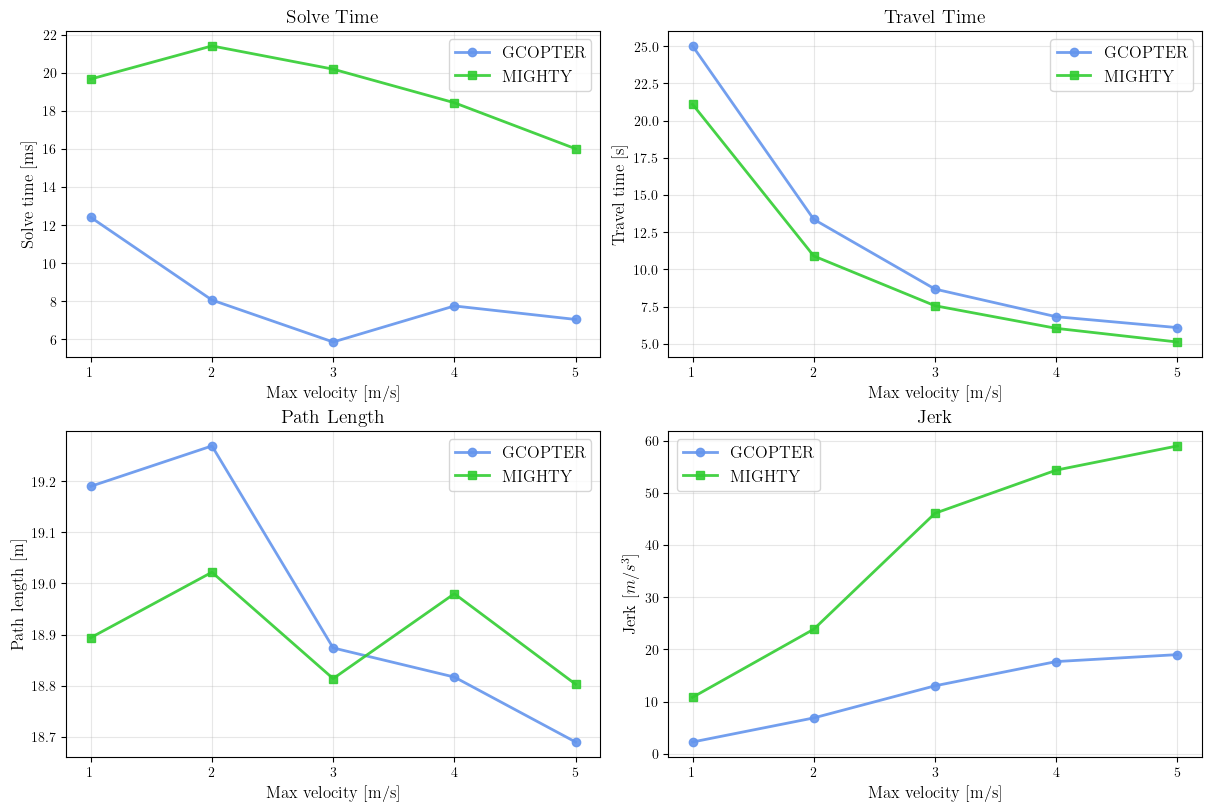

In [16]:
# ======================= Plot GCOPTER/MIGHTY vs velocity (single dir) =======================
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------- User paths ---------------------
PATH_DATA = ROOT_DIR
FIG_SAVE_DIR = Path("/media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/fig_out")
FIG_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --------------------- Helpers ---------------------
def _resolve_case_csv(p: Path) -> Path:
    """Return path to analysis_summary/case_summary.csv whether p is a dir or the CSV itself."""
    if p.is_dir():
        candidate = p / "analysis_summary" / "case_summary.csv"
        if not candidate.exists():
            raise FileNotFoundError(f"Expected {candidate} in directory {p}")
        return candidate
    if p.suffix.lower() == ".csv":
        return p
    raise FileNotFoundError(f"Provide a directory containing analysis_summary/case_summary.csv or a CSV path, got: {p}")

def _parse_v_from_case(case_name: str):
    """Parse velocity (float) from case string like 'case_00000_v1.00_jw1e-1'."""
    m = re.search(r"_v([0-9.]+)", case_name)
    if m:
        try:
            return float(m.group(1))
        except Exception:
            return np.nan
    return np.nan

def _load_cases_with_v(csv_path: Path) -> pd.DataFrame:
    """Load case_summary.csv and add a 'v' column (from 'max_vel' or parsed from 'case')."""
    df = pd.read_csv(csv_path)
    # Prefer 'max_vel' if present and valid; otherwise parse from 'case'
    if "max_vel" in df.columns:
        v_col = pd.to_numeric(df["max_vel"], errors="coerce")
    else:
        v_col = pd.Series([_parse_v_from_case(c) for c in df["case"]], name="v")
    if v_col.isna().all():
        v_col = pd.Series([_parse_v_from_case(c) for c in df["case"]], name="v")
    df["v"] = v_col
    return df

def _group_by_v_means(df: pd.DataFrame, cols):
    """Return a DataFrame indexed by v with mean of requested cols."""
    out = df.groupby("v")[cols].mean().sort_index()
    return out

def _plot_metric(ax, x, series, title, ylabel):
    """
    series: dict key -> (y_values ndarray, style dict)
      style dict may include label, color, linestyle, marker, alpha, linewidth
    """
    for key, (y, st) in series.items():
        ax.plot(x, y, **st)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Max velocity [m/s]", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sorted(x))
    ax.legend(fontsize=12, ncols=1)

# --------------------- Load and aggregate ---------------------
csv_path = _resolve_case_csv(PATH_DATA)
df = _load_cases_with_v(csv_path)

# Metrics to pull
cols_gc = ["gc_solve_ms","gc_time_s","gc_path_len","gc_jerk"]
cols_my = ["my_solve_ms","my_time_s","my_path_len","my_jerk"]
needed = [c for c in (cols_gc + cols_my) if c in df.columns]
missing = set(cols_gc + cols_my) - set(df.columns)
if missing:
    print(f"[warn] Missing columns in CSV: {sorted(missing)}")

g = _group_by_v_means(df, needed)
x = g.index.to_list()
x_arr = np.array(x, dtype=float)

# --------------------- Styling ---------------------
styles = {
    "gc": dict(label="GCOPTER", color="cornflowerblue", linestyle="-", marker="o", alpha=0.9, linewidth=2),
    "my": dict(label="MIGHTY",  color="limegreen",      linestyle="-", marker="s", alpha=0.9, linewidth=2),
}

# --------------------- Build series per metric ---------------------
def _series_for(metric_gc, metric_my):
    ser = {}
    if metric_gc in g.columns:
        ser["gc"] = (g[metric_gc].to_numpy(), styles["gc"])
    if metric_my in g.columns:
        ser["my"] = (g[metric_my].to_numpy(), styles["my"])
    return ser

series_solve = _series_for("gc_solve_ms", "my_solve_ms")
series_time  = _series_for("gc_time_s",   "my_time_s")
series_path  = _series_for("gc_path_len", "my_path_len")
series_jerk  = _series_for("gc_jerk",     "my_jerk")

# --------------------- Make a 2x2 panel ---------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
(ax11, ax12), (ax21, ax22) = axs

_plot_metric(ax11, x_arr, series_solve, "Solve Time", "Solve time [ms]")
# ax11.set_yscale("log")  # optional

_plot_metric(ax12, x_arr, series_time,  "Travel Time", "Travel time [s]")
_plot_metric(ax21, x_arr, series_path,  "Path Length", "Path length [m]")
_plot_metric(ax22, x_arr, series_jerk,  "Jerk",        r"Jerk [$m/s^3$]")

# --------------------- MIGHTY vs GCOPTER summaries (travel, solve, path, jerk) ---------------------
def _reduction(ref_series, alt_series):
    """Return (abs, pct) = (ref - alt, (ref-alt)/ref*100). 'ref' is MIGHTY here."""
    ref = pd.to_numeric(ref_series, errors="coerce")
    alt = pd.to_numeric(alt_series, errors="coerce")
    abs_s = ref - alt
    denom = ref.replace(0, np.nan)
    pct = (abs_s / denom) * 100.0
    return abs_s, pct

def _print_section(title, abs_col, pct_col, unit, df):
    print(f"\n=== {title} ===")
    sub = df[["v", abs_col, pct_col]].dropna()
    if sub.empty:
        print("No comparable entries.")
        return
    for _, r in sub.iterrows():
        print(f"v={r['v']:.2g}: Δ={r[abs_col]:+.3f} {unit} ({r[pct_col]:+.1f}%)")
    print(f"--- Averages over available v ---")
    print(f"mean Δ: {np.nanmean(sub[abs_col]):+.3f} {unit}, mean %: {np.nanmean(sub[pct_col]):+.1f}%")
    print(f"   min %: {np.nanmin(sub[pct_col]):+.1f}%, max %: {np.nanmax(sub[pct_col]):+.1f}%")

def _summarize_metric(name, unit, my_col, gc_col, out_filename):
    if my_col in g.columns and gc_col in g.columns:
        dfm = pd.DataFrame({
            "v": x_arr,
            gc_col: g[gc_col].to_numpy(),
            my_col: g[my_col].to_numpy(),
        })
        dfm["my_vs_gc_abs"], dfm["my_vs_gc_pct"] = _reduction(dfm[my_col], dfm[gc_col])
        _print_section(f"MIGHTY vs GCOPTER ({name})", "my_vs_gc_abs", "my_vs_gc_pct", unit, dfm)
        out_csv = FIG_SAVE_DIR / out_filename
        dfm.round(4).to_csv(out_csv, index=False)
        print(f"[ok] Saved {out_csv}")
    else:
        print(f"[warn] Cannot compute {name} summary (missing columns: need '{my_col}' and '{gc_col}').")

_summarize_metric("Travel Time", "s",     "my_time_s",   "gc_time_s",   "travel_time_summary_single.csv")
_summarize_metric("Solve Time",  "ms",    "my_solve_ms", "gc_solve_ms", "solve_time_summary_single.csv")
_summarize_metric("Path Length", "m",     "my_path_len", "gc_path_len", "path_length_summary_single.csv")
_summarize_metric("Jerk",        "m/s^3", "my_jerk",     "gc_jerk",     "jerk_summary_single.csv")

# --------------------- Save figures ---------------------
panel_path = FIG_SAVE_DIR / "lines_2x2.png"
fig.savefig(panel_path, dpi=300)
print(f"[ok] Saved {panel_path}")

def _save_single(metric_name, series, ylabel, fname):
    f, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    _plot_metric(ax, x_arr, series, metric_name, ylabel)
    out = FIG_SAVE_DIR / fname
    f.savefig(out, dpi=300)
    plt.close(f)
    print(f"[ok] Saved {out}")

_save_single("Solve Time", series_solve, "Solve time [ms]", "solve_time_lines.png")
_save_single("Travel Time", series_time, "Travel time [s]", "travel_time_lines.png")
_save_single("Path Length", series_path, "Path length [m]", "path_length_lines.png")
_save_single("Jerk", series_jerk, r"Jerk [$m/s^3$]", "jerk_lines.png")

# --------------------- Quick sanity print ---------------------
print("Velocities present:", x)
print(f"Source CSV: {csv_path}")


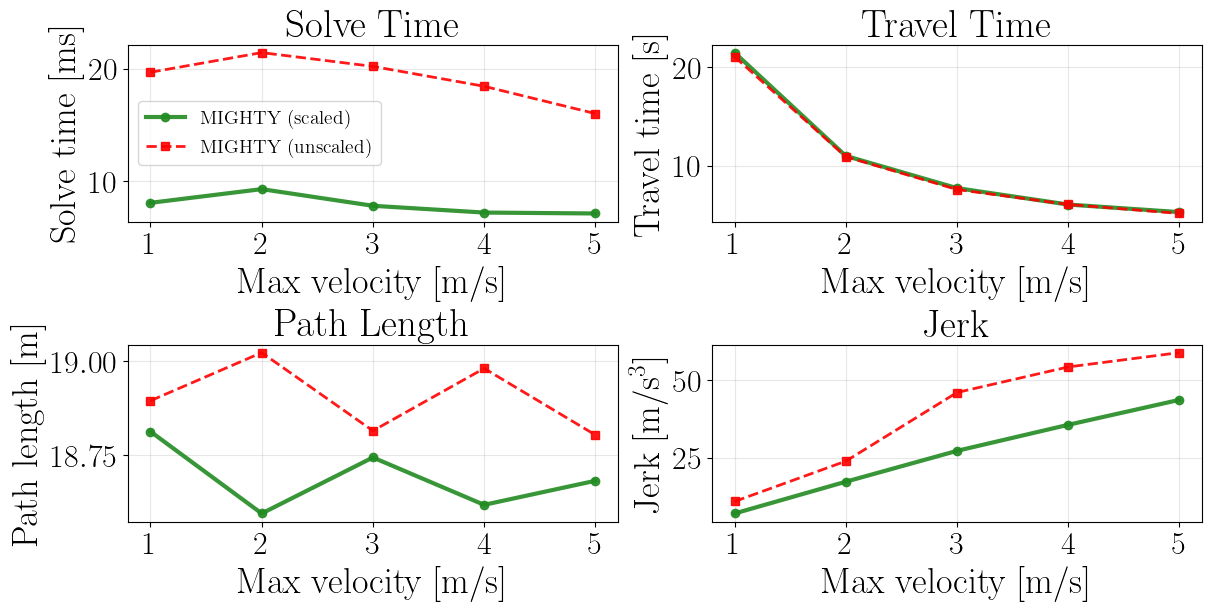

[ok] Saved /media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/fig_out_scaled_vs_unscaled/mighty_scaled_vs_unscaled_2x2.pdf
[ok] Saved /media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/fig_out_scaled_vs_unscaled/solve_time_scaled_vs_unscaled.png
[ok] Saved /media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/fig_out_scaled_vs_unscaled/travel_time_scaled_vs_unscaled.png
[ok] Saved /media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/fig_out_scaled_vs_unscaled/path_length_scaled_vs_unscaled.png
[ok] Saved /media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/fig_out_scaled_vs_unscaled/jerk_scaled_vs_unscaled.png

=== Scaled vs Unscaled (Travel Time) (Δ = Unscaled − Scaled; positive = scaled better) ===
v=1: Δ=-0.415 s (-2.0%)
v=2: Δ=-0.085 s (-0.8%)
v=3: Δ=-0.145 s (-1.9%)
v=4: Δ=+0.011 s (+0.2%)
v=5: Δ=-0.139 s (-2.7%)
--- Averages over available v ---
mean Δ: -0.155 s, mean %: -1.4%
   min %: -2.7%, max %: +0.2%
[ok] Saved /media/kkondo/lucas_pro/mighty_gcopter_b

In [28]:
# ======================= MIGHTY (scaled) vs MIGHTY (unscaled) =======================
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 14 + 10,        # base font
    "axes.titlesize": 18 + 10,   # subplot titles
    "axes.labelsize": 16 + 10,   # x/y labels
    "xtick.labelsize": 13 + 10,
    "ytick.labelsize": 13 + 10,
    "legend.fontsize": 13 + 10,  # legend text
    # optional polish:
    # "axes.titleweight": "semibold",
    # "figure.titlesize": 20,
})

# --------------------- User paths ---------------------
# Scaled (proposed) vs Unscaled roots (dirs or CSV paths)
PATH_SCALED_ROOT   = Path("/media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/data3")  # scaled / proposed
PATH_UNSCALED_ROOT = Path("/media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/data4")  # unscaled / baseline

FIG_SAVE_DIR = Path("/media/kkondo/lucas_pro/mighty_gcopter_bench/sweep_bench/fig_out_scaled_vs_unscaled")
FIG_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --------------------- Helpers ---------------------
def _resolve_case_csv(p: Path) -> Path:
    """Return path to analysis_summary/case_summary.csv whether p is a dir or the CSV itself."""
    if p.is_dir():
        candidate = p / "analysis_summary" / "case_summary.csv"
        if not candidate.exists():
            raise FileNotFoundError(f"Expected {candidate} in directory {p}")
        return candidate
    if p.suffix.lower() == ".csv":
        return p
    raise FileNotFoundError(f"Provide a directory containing analysis_summary/case_summary.csv or a CSV path, got: {p}")

def _parse_v_from_case(case_name: str):
    """Parse velocity (float) from case string like 'case_00000_v1.00_jw1e-1'."""
    m = re.search(r"_v([0-9.]+)", case_name)
    if m:
        try:
            return float(m.group(1))
        except Exception:
            return np.nan
    return np.nan

def _load_cases_with_v(csv_path: Path) -> pd.DataFrame:
    """Load case_summary.csv and add a 'v' column (from 'max_vel' or parsed from 'case')."""
    df = pd.read_csv(csv_path)
    if "max_vel" in df.columns:
        v_col = pd.to_numeric(df["max_vel"], errors="coerce")
    else:
        v_col = pd.Series([_parse_v_from_case(c) for c in df["case"]], name="v")
    if v_col.isna().all():
        v_col = pd.Series([_parse_v_from_case(c) for c in df["case"]], name="v")
    df["v"] = v_col
    return df

def _group_by_v_means(df: pd.DataFrame, cols):
    """Return a DataFrame indexed by v with mean of requested cols."""
    cols = [c for c in cols if c in df.columns]
    if not cols:
        return pd.DataFrame(index=pd.Index([], name="v"))
    out = df.groupby("v")[cols].mean().sort_index()
    out.index.name = "v"
    return out

def _plot_metric(ax, x, series, title, ylabel):
    """
    series: dict key -> (y_values ndarray, style dict)
      style dict may include label, color, linestyle, marker, alpha, linewidth
    """
    for key, (y, st) in series.items():
        ax.plot(x, y, **st)
    ax.set_title(title)
    ax.set_xlabel("Max velocity [m/s]")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sorted(x))
    ax.legend(fontsize=14, ncols=1)

# --------------------- Load and aggregate (both folders) ---------------------
CSV_SCALED   = _resolve_case_csv(PATH_SCALED_ROOT)
CSV_UNSCALED = _resolve_case_csv(PATH_UNSCALED_ROOT)

df_s = _load_cases_with_v(CSV_SCALED)
df_u = _load_cases_with_v(CSV_UNSCALED)

my_cols = ["my_solve_ms","my_time_s","my_path_len","my_jerk"]

missing_s = set(my_cols) - set(df_s.columns)
missing_u = set(my_cols) - set(df_u.columns)
if missing_s:
    print(f"[warn] Scaled CSV missing: {sorted(missing_s)}")
if missing_u:
    print(f"[warn] Unscaled CSV missing: {sorted(missing_u)}")

g_s = _group_by_v_means(df_s, my_cols)
g_u = _group_by_v_means(df_u, my_cols)

# Union of velocities present in either dataset (sorted)
x_vals = sorted(set(g_s.index.tolist()) | set(g_u.index.tolist()))
x_arr = np.array(x_vals, dtype=float)

def _series_for(col):
    ser = {}
    if col in g_s.columns:
        ser["scaled"] = (
            g_s.reindex(x_vals)[col].to_numpy(),
            dict(
                label="MIGHTY (scaled)",
                color="forestgreen",     # << add
                linestyle="-",
                marker="o",
                alpha=0.9,
                linewidth=3,
            ),
        )
    if col in g_u.columns:
        ser["unscaled"] = (
            g_u.reindex(x_vals)[col].to_numpy(),
            dict(
                label="MIGHTY (unscaled)",
                color="red",             # << add
                linestyle="--",
                marker="s",
                alpha=0.9,
                linewidth=2,
            ),
        )
    return ser

series_solve = _series_for("my_solve_ms")
series_time  = _series_for("my_time_s")
series_path  = _series_for("my_path_len")
series_jerk  = _series_for("my_jerk")

# --------------------- Plot 2x2 panel ---------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 6), constrained_layout=True)
(ax11, ax12), (ax21, ax22) = axs

_plot_metric(ax11, x_arr, series_solve, "Solve Time", "Solve time [ms]")
# ax11.set_yscale("log")  # optional

_plot_metric(ax12, x_arr, series_time,  "Travel Time", "Travel time [s]")
_plot_metric(ax21, x_arr, series_path,  "Path Length", "Path length [m]")
_plot_metric(ax22, x_arr, series_jerk,  "Jerk",        r"Jerk [m/s$^3$]")

for ax in (ax12, ax21, ax22):
    leg = ax.get_legend()
    if leg:
        leg.remove()

panel_path = FIG_SAVE_DIR / "mighty_scaled_vs_unscaled_2x2.pdf"
fig.savefig(panel_path, dpi=300)
plt.show()
# plt.close(fig)
print(f"[ok] Saved {panel_path}")

# --------------------- Per-metric plots ---------------------
def _save_single(metric_name, series, ylabel, fname):
    f, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    _plot_metric(ax, x_arr, series, metric_name, ylabel)
    out = FIG_SAVE_DIR / fname
    f.savefig(out, dpi=300)
    plt.close(f)
    print(f"[ok] Saved {out}")

_save_single("Computation Time", series_solve, "Comp. time [ms]", "solve_time_scaled_vs_unscaled.png")
_save_single("Travel Time", series_time, "Travel time [s]", "travel_time_scaled_vs_unscaled.png")
_save_single("Path Length", series_path, "Path length [m]", "path_length_scaled_vs_unscaled.png")
_save_single("Jerk", series_jerk, r"Jerk [$m/s^3$]", "jerk_scaled_vs_unscaled.png")

# --------------------- Scaled vs Unscaled summaries (Δ = Unscaled − Scaled) ---------------------
def _reduction(unscaled_series, scaled_series):
    """Return (abs, pct) = (unscaled - scaled, (unscaled - scaled)/unscaled*100).
       Positive => scaled improved (reduced the metric)."""
    un = pd.to_numeric(unscaled_series, errors="coerce")
    sc = pd.to_numeric(scaled_series,   errors="coerce")
    abs_s = un - sc
    pct = (abs_s / un.replace(0, np.nan)) * 100.0
    return abs_s, pct

def _print_section(title, abs_col, pct_col, unit, df):
    print(f"\n=== {title} (Δ = Unscaled − Scaled; positive = scaled better) ===")
    sub = df[["v", abs_col, pct_col]].dropna()
    if sub.empty:
        print("No comparable entries.")
        return
    for _, r in sub.iterrows():
        print(f"v={r['v']:.2g}: Δ={r[abs_col]:+.3f} {unit} ({r[pct_col]:+.1f}%)")
    print(f"--- Averages over available v ---")
    print(f"mean Δ: {np.nanmean(sub[abs_col]):+.3f} {unit}, mean %: {np.nanmean(sub[pct_col]):+.1f}%")
    print(f"   min %: {np.nanmin(sub[pct_col]):+.1f}%, max %: {np.nanmax(sub[pct_col]):+.1f}%")

def _summarize_metric(name, unit, col, out_filename):
    have = (col in g_s.columns) and (col in g_u.columns)
    if not have:
        print(f"[warn] Cannot compute {name} summary (missing '{col}' in one of the CSVs).")
        return
    dfm = pd.DataFrame({
        "v": x_arr,
        "scaled":   g_s.reindex(x_vals)[col].to_numpy(),
        "unscaled": g_u.reindex(x_vals)[col].to_numpy(),
    })
    dfm["Δ_abs"], dfm["Δ_pct"] = _reduction(dfm["unscaled"], dfm["scaled"])
    _print_section(f"Scaled vs Unscaled ({name})", "Δ_abs", "Δ_pct", unit, dfm)
    out_csv = FIG_SAVE_DIR / out_filename
    dfm.round(4).to_csv(out_csv, index=False)
    print(f"[ok] Saved {out_csv}")

_summarize_metric("Travel Time", "s",     "my_time_s",   "travel_time_scaled_vs_unscaled.csv")
_summarize_metric("Solve Time",  "ms",    "my_solve_ms", "solve_time_scaled_vs_unscaled.csv")
_summarize_metric("Path Length", "m",     "my_path_len", "path_length_scaled_vs_unscaled.csv")
_summarize_metric("Jerk",        "m/s^3", "my_jerk",     "jerk_scaled_vs_unscaled.csv")

# --------------------- Quick sanity print ---------------------
print("Velocities present (union):", x_vals)
print(f"Scaled CSV:   {CSV_SCALED}")
print(f"Unscaled CSV: {CSV_UNSCALED}")


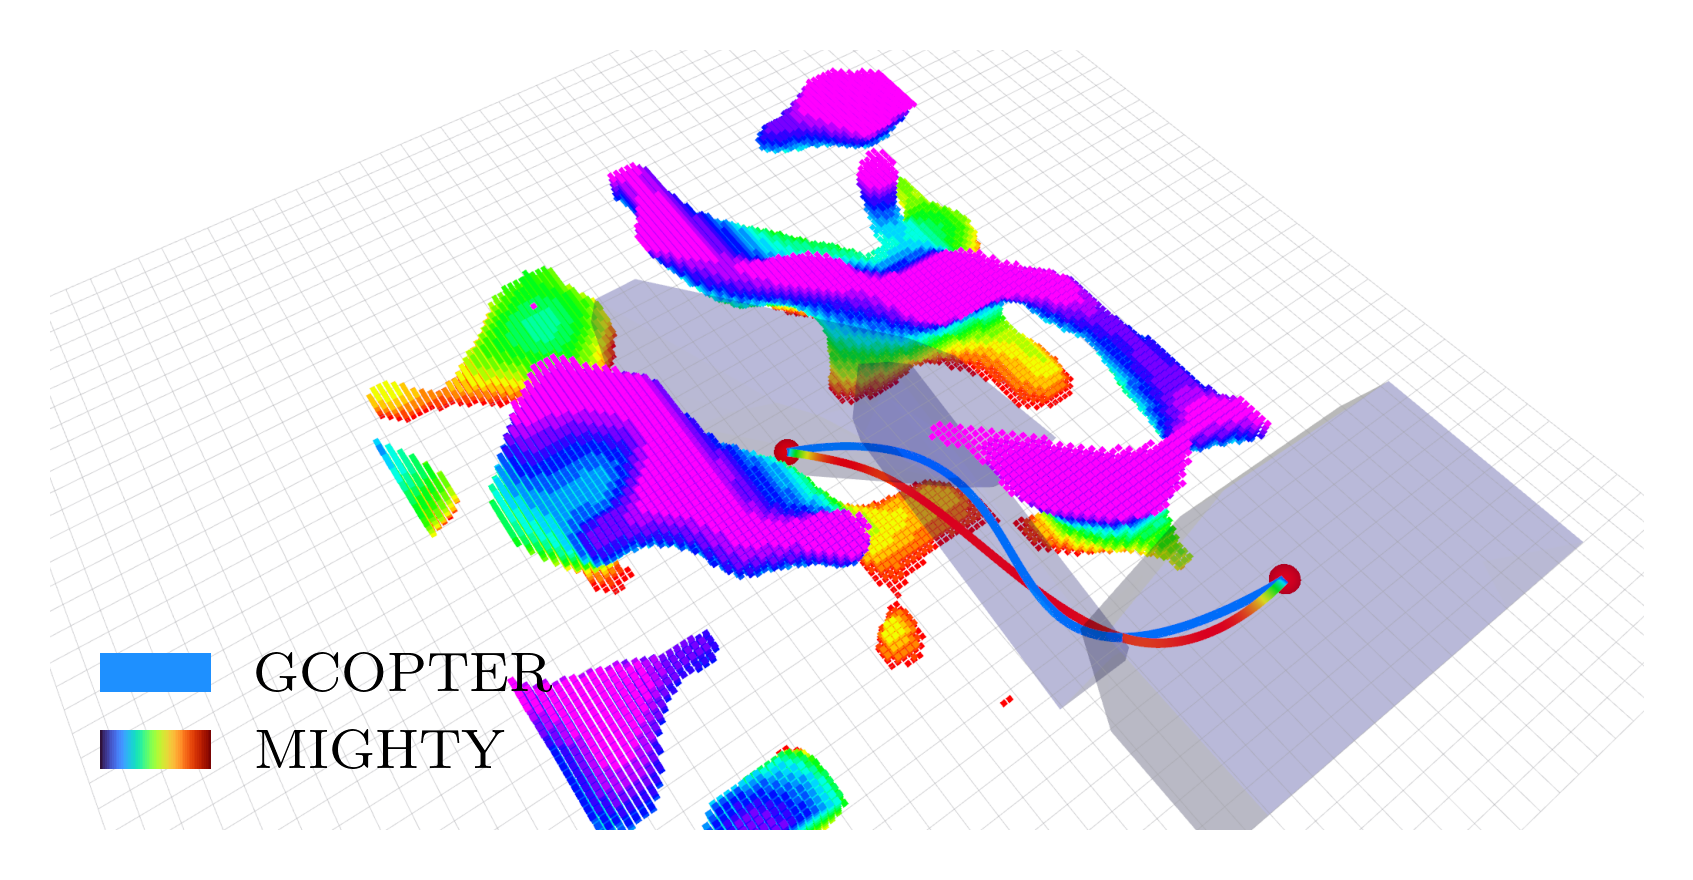

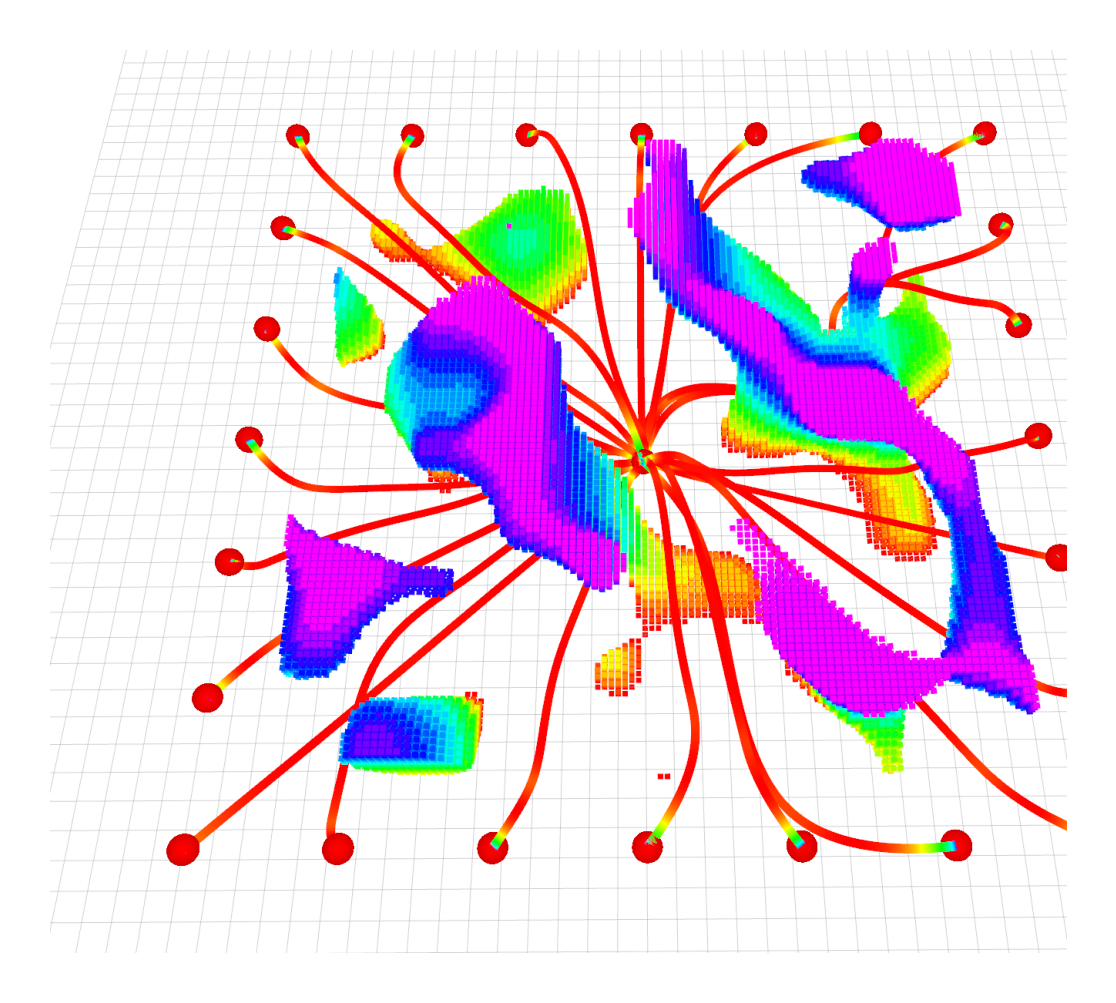

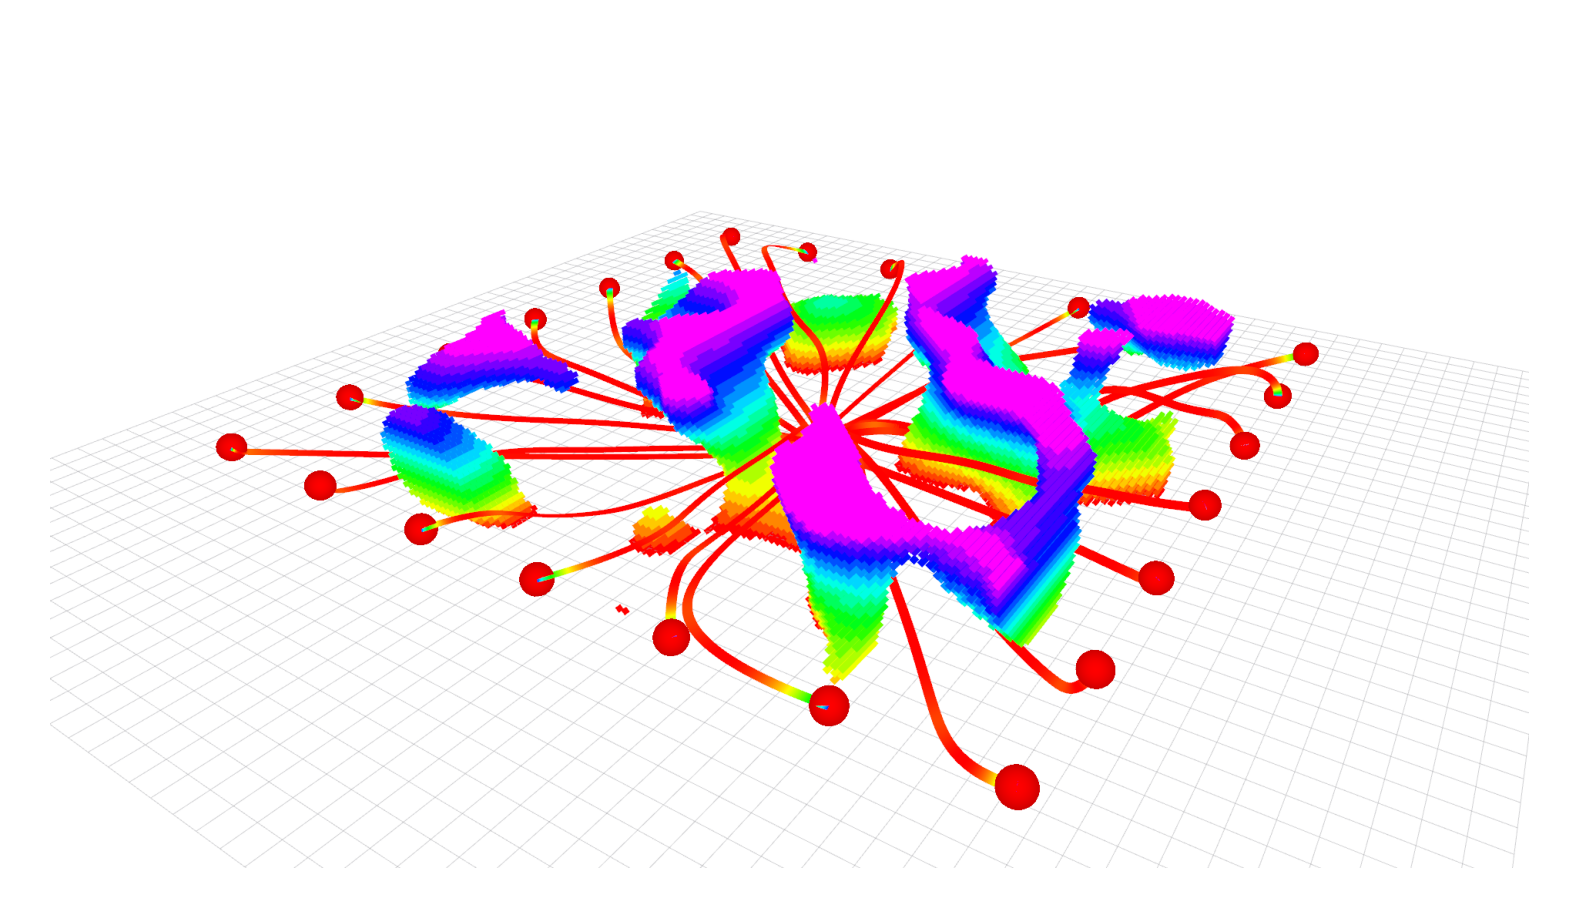

In [126]:
# Trim white-ish border (auto), add legend, save
_ = trim_add_legend_save(
    img_input="/home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/complex_bench/complex_bench_data3_example.png",
    out_path="/home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/complex_bench/paper_ready_complex_bench_data3_example.png",
    cut=(800, 200, 500, 200),
    legend_items=[("GCOPTER","dodgerblue"), ("MIGHTY","rainbow")],
    legend_loc="lower left",
    legend_title="",
    legend_box=False,  # no frame around legend box
    dpi=500,
    hide_axes=True,
    show=True,
    # Add labels (axes-fraction positions)
    pos_mode="axes"
)

# Trim white-ish border (auto), add legend, save
_ = trim_add_legend_save(
    img_input="/home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/complex_bench/complex_bench_data3_top.png",
    out_path="/home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/complex_bench/paper_ready_complex_bench_data3_top.png",
    cut=(1100, 120, 950, 120),
    dpi=500,
    hide_axes=True,
    show=True,
    # Add labels (axes-fraction positions)
    pos_mode="axes"
)

# Trim white-ish border (auto), add legend, save
_ = trim_add_legend_save(
    img_input="/home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/complex_bench/complex_bench_data3_angled.png",
    out_path="/home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/complex_bench/paper_ready_complex_bench_data3_angled.png",
    cut=(900, 200, 550, 150),
    dpi=500,
    hide_axes=True,
    show=True,
    # Add labels (axes-fraction positions)
    pos_mode="axes"
)

Saved: /home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/complex_bench/paper_ready_complex_bench_combined.png Size: (1923, 943)


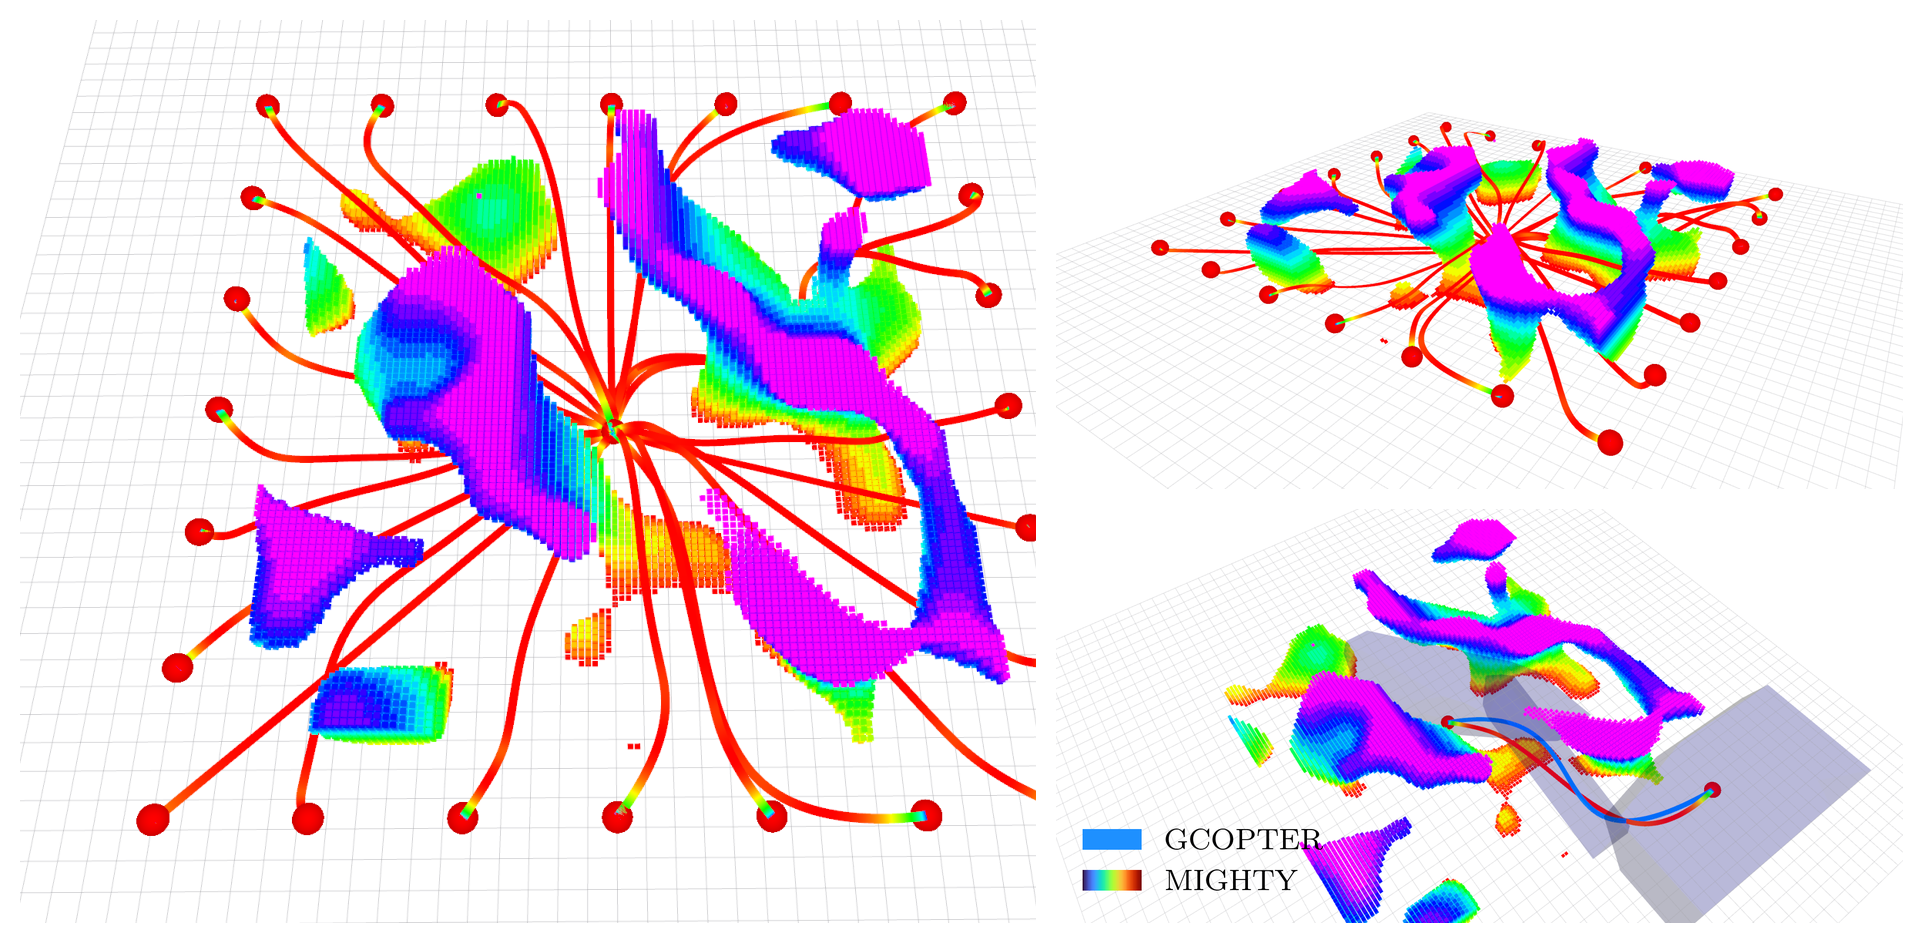

In [127]:
from PIL import Image, ImageOps
import os
from PIL import Image, ImageOps
import os

def collage_left_plus_two_right(
    left_path: str,
    top_right_path: str,
    bottom_right_path: str,
    out_path: str,
    *,
    height: int | None = None,
    padding: int = 0,         # inner gap between columns and between the two right images
    margin: int = 0,          # outer whitespace all around the collage
    bg_color: tuple[int, int, int] = (255, 255, 255),
) -> tuple[str, tuple[int, int]]:
    """
    Compose three images as:
        [ left ]  [ top_right ]
                   [ bottom_right ]

    - height: final collage inner height (excluding outer margin). If None, uses the left image's height.
    - padding: inner gap between left & right columns and between the two right images.
    - margin: outer whitespace around the whole collage.
    - bg_color: RGB background color for padding/margin & to flatten transparency.

    Returns (out_path, (final_width, final_height)).
    """

    # Load with EXIF orientation fixed
    L  = ImageOps.exif_transpose(Image.open(left_path))
    TR = ImageOps.exif_transpose(Image.open(top_right_path))
    BR = ImageOps.exif_transpose(Image.open(bottom_right_path))

    # Flatten transparency onto background
    def to_rgb(im: Image.Image, bg=(255, 255, 255)) -> Image.Image:
        if im.mode in ("RGBA", "LA") or (im.mode == "P" and "transparency" in im.info):
            base = Image.new("RGB", im.size, bg)
            base.paste(im, mask=im.split()[-1] if im.mode in ("RGBA", "LA") else None)
            return base
        return im.convert("RGB")

    L, TR, BR = (to_rgb(L, bg_color), to_rgb(TR, bg_color), to_rgb(BR, bg_color))

    # Dimensions
    w1, h1 = L.size
    w2, h2 = TR.size
    w3, h3 = BR.size

    if height is None:
        H = h1
    else:
        H = int(height)
    if H <= 0:
        raise ValueError("height must be a positive integer")

    padding = max(0, int(padding))
    margin  = max(0, int(margin))

    # Right column usable inner height (split between top-right and bottom-right)
    effective_right_h = max(1, H - padding)

    # Compute right column width so the two resized heights sum to effective_right_h
    denom = (h2 / w2) + (h3 / w3)
    if denom <= 0:
        raise ValueError("Invalid image dimensions encountered.")
    wr = int(round(effective_right_h / denom))

    # Heights for right images; adjust by 1–2 px if rounding drifts
    hr2 = int(round(h2 * wr / w2))
    hr3 = int(round(h3 * wr / w3))
    drift = effective_right_h - (hr2 + hr3)
    hr3 += drift  # ensures hr2 + hr3 == effective_right_h

    # Left image width after scaling to inner height H
    wl = int(round(w1 * (H / h1)))

    # Resize with high-quality filter
    Lr  = L.resize((wl, H), Image.Resampling.LANCZOS)
    TRr = TR.resize((wr, hr2), Image.Resampling.LANCZOS)
    BRr = BR.resize((wr, hr3), Image.Resampling.LANCZOS)

    # Canvas size includes outer margin
    inner_w = wl + wr + (padding if wr > 0 else 0)
    final_w = inner_w + 2 * margin
    final_h = H + 2 * margin
    canvas = Image.new("RGB", (final_w, final_h), bg_color)

    # Paste positions with margins and inner padding
    x_left   = margin
    y_left   = margin
    x_right  = margin + wl + (padding if wr > 0 else 0)
    y_top    = margin
    y_bottom = margin + hr2 + (padding if wr > 0 else 0)

    canvas.paste(Lr,  (x_left, y_left))
    canvas.paste(TRr, (x_right, y_top))
    canvas.paste(BRr, (x_right, y_bottom))

    # Save
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    canvas.save(out_path)
    return out_path, (final_w, final_h)

from PIL import Image
from IPython.display import display

out_path = "/home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/complex_bench/paper_ready_complex_bench_combined.png"  # e.g., "results/collage.png"

# Your three inputs
left   = "/home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/complex_bench/paper_ready_complex_bench_data3_top.png"
topR   = "/home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/complex_bench/paper_ready_complex_bench_data3_angled.png"
botR   = "/home/kkondo/paper_writing/mighty_paper/mighty_paper/figures/complex_bench/paper_ready_complex_bench_data3_example.png"

# Make the collage (optional: height=1000, padding=12, bg_color=(245,245,245))
saved_path, size = collage_left_plus_two_right(
    left, topR, botR, out_path,
    height=None,     # or set an explicit height like 1000
    padding=20,      # gap between panels
    margin=20,
    bg_color=(255, 255, 255)
)

print("Saved:", saved_path, "Size:", size)
display(Image.open(saved_path))
